## *Titanic EDA Part*

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy.stats import pearsonr

### **Data Loading**

In [119]:
# Load the dataset of both training and testing data of the Titanic dataset
eda_data = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_data = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
gender_submission = pd.read_csv('/kaggle/input/competitions/titanic/gender_submission.csv')

In [120]:
# separate EDA and ML dataset
eda_data = eda_data.copy()
ml_data = eda_data.copy()

### **Dataset Overview**

In [121]:
eda_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [122]:
eda_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [123]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


### **Missing Value Inspection**

In [124]:
#show null value of both train and test dataset in tabulated format
Missing_table = pd.DataFrame({
    'Train_Missing': eda_data.isnull().sum(),
    'Test_Missing': test_data.isnull().sum(),
    'Per_Train_Missing': (eda_data.isnull().mean()*100).round(2),
    'Per_Test_Missing': (test_data.isnull().mean()*100).round(2)
})
Missing_table

,Train_Missing,Test_Missing,Per_Train_Missing,Per_Test_Missing
Age,177,86.0,19.87,20.57
Cabin,687,327.0,77.10,78.23
Embarked,2,0.0,0.22,0.00
Fare,0,1.0,0.00,0.24
Name,0,0.0,0.00,0.00
Parch,0,0.0,0.00,0.00
PassengerId,0,0.0,0.00,0.00
Pclass,0,0.0,0.00,0.00
Sex,0,0.0,0.00,0.00
SibSp,0,0.0,0.00,0.00


<Axes: >

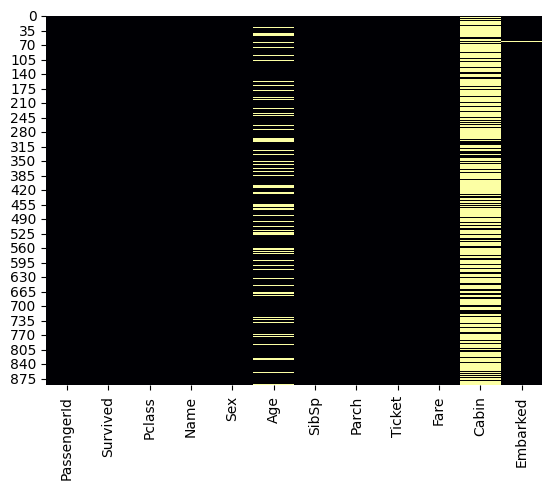

In [125]:
sb.heatmap(eda_data.isnull(), cbar=False, cmap='inferno')

### **Investigating Missing Values in `Embarked` and the Imputation Strategy**

In [126]:
#Checking Embarked column for missing value or nan value on eda_data  

missing_rows = eda_data[eda_data['Embarked'].isnull()]
missing_rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [127]:
# Show fare summary for all 3 classes by embarkation port
print(
    eda_data[eda_data['Pclass'].isin([1, 2, 3])]
    .groupby(['Pclass', 'Embarked'])['Fare']
    .describe()
)

                 count        mean        std      min      25%      50%  \
Pclass Embarked                                                            
1      C          85.0  104.718529  99.093935  26.5500  49.5000  78.2667   
       Q           2.0   90.000000   0.000000  90.0000  90.0000  90.0000   
       S         127.0   70.364862  58.811278   0.0000  29.2500  52.0000   
2      C          17.0   25.358335  11.345067  12.0000  13.8625  24.0000   
       Q           3.0   12.350000   0.000000  12.3500  12.3500  12.3500   
       S         164.0   20.327439  13.630741   0.0000  13.0000  13.5000   
3      C          66.0   11.214083   4.871528   4.0125   7.2292   7.8958   
       Q          72.0   11.183393   6.721677   6.7500   7.7500   7.7500   
       S         353.0   14.644083  13.276609   0.0000   7.8542   8.0500   

                        75%       max  
Pclass Embarked                        
1      C         110.883300  512.3292  
       Q          90.000000   90.0000  
   

In [128]:
eda_data[
    (eda_data['Pclass'] == 1) &
    (eda_data['Fare'].between(75, 85))
].groupby('Embarked').size()

Embarked
C    16
S    13
dtype: int64

<Axes: >

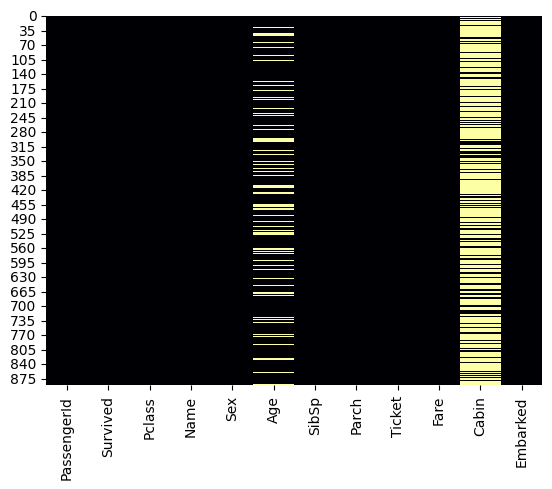

In [129]:
eda_data['Embarked'] = eda_data['Embarked'].fillna('S')
sb.heatmap(eda_data.isnull(), cbar=False, cmap='inferno')

**Why were the missing `Embarked` values filled with `'S'`?**

There are only **2 missing values** in the `Embarked` column, and both passengers share very similar details:

- **Passenger class:** 1  
- **Cabin:** B28  
- **Fare:** 80  

To decide the most likely embarkation port, the fare and class were compared with other passengers in the dataset. For **first-class passengers**, a fare around **80** is more commonly associated with **Southampton (`'S'`)** than the other ports.

Because both passengers have the same ticket information, cabin, class, and fare, it is reasonable to assume they boarded from the same location. Therefore, the missing `Embarked` values were filled with **`'S'` (Southampton)**.

<Axes: >

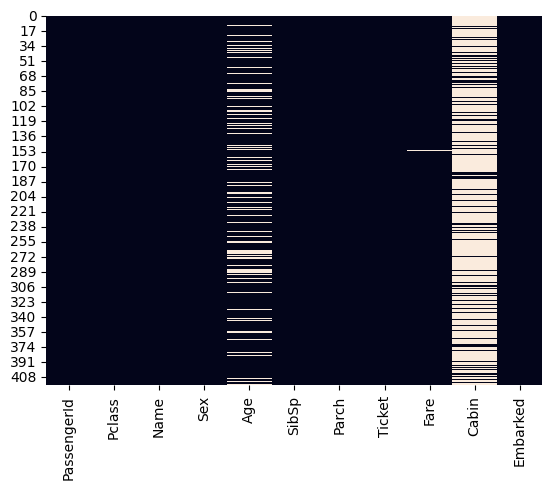

In [130]:
sb.heatmap(test_data.isnull(), cbar=False)

### **Data Duplication Inspection**

### Checking for duplicate data in both sets

In [131]:
duplicate_table = pd.DataFrame({
    'Train_Duplicates': [eda_data.duplicated().sum()],
    'Test_Duplicates': [test_data.duplicated().sum()],
    'Per_Train_Duplicates': [round(eda_data.duplicated().mean() * 100, 2)],
    'Per_Test_Duplicates': [round(test_data.duplicated().mean() * 100, 2)]
})
duplicate_table

,Train_Duplicates,Test_Duplicates,Per_Train_Duplicates,Per_Test_Duplicates
0,0,0,0.0,0.0


#### **Transformed categorical data of `Gender` into numerical**

In [132]:
#change the value of 'Sex' column object to integer for better analysis and modeling
# convert Sex to numeric safely (with fallback if the column was already corrupted to NaN)
sex_map = {'male': 1, 'female': 0}
test_data['Sex'] = test_data['Sex'].map(sex_map).fillna(test_data['Sex'])
eda_data['Sex'] = eda_data['Sex'].map(sex_map).fillna(eda_data['Sex'])
print(eda_data.head())
print(test_data.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare Cabin Embarked  
0         A/5 21171   7.2500   NaN        S  
1          PC 17599  71.2833   C85        C  
2  STON/O2. 3101282   7.9250   NaN        S  
3            113803  53.1000  C123        S  
4            373450   8.0500   NaN        S  
   PassengerId  Pcla

In [133]:
print(eda_data['Sex'].unique())
print(eda_data['Sex'].head())
print(test_data['Sex'].unique())
print(test_data['Sex'].head())

[1 0]
0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64
[1 0]
0    1
1    0
2    1
3    1
4    0
Name: Sex, dtype: int64


### **Analysing missing rows of `Age` from both sets and find normalised ideal `Age` to use in ML purpose**

In [134]:
#show min and max value of 'Age' column according to 'Pclass' column in table format
print(eda_data.groupby('Pclass')['Age'].agg(['min', 'max']))
print(test_data.groupby('Pclass')['Age'].agg(['min', 'max']))


         min   max
Pclass            
1       0.92  80.0
2       0.67  70.0
3       0.42  74.0
         min   max
Pclass            
1       6.00  76.0
2       0.92  63.0
3       0.17  60.5


In [135]:
#show total rows of 'Age' missing rows with 'Sex' according to 'Pclass' column in table format
missing_rows_train = eda_data[eda_data['Age'].isnull()]
train_missing_age_table = (
    missing_rows_train.groupby(['Pclass', 'Sex'])
    .size()
    .to_frame(name='Missing_Age_Count')
)

missing_rows_test = test_data[test_data['Age'].isnull()]
test_missing_age_table = (
    missing_rows_test.groupby(['Pclass', 'Sex'])
    .size()
    .to_frame(name='Missing_Age_Count')
)
print(train_missing_age_table, "\n")
print(test_missing_age_table)

            Missing_Age_Count
Pclass Sex                   
1      0                    9
       1                   21
2      0                    2
       1                    9
3      0                   42
       1                   94 

            Missing_Age_Count
Pclass Sex                   
1      0                    2
       1                    7
2      0                    1
       1                    4
3      0                   22
       1                   50


In [136]:
# Avg Age of dead/survived passengers by Pclass and Sex in one table
# 'Survived':  0== dead, 1== survived
# rename Sex column to 0 for male and 1 for female for this display only    

Train_Surivial_age_summary = eda_data.groupby(['Pclass', 'Sex', 'Survived','Embarked'])['Age'].mean().round(0).unstack(level='Survived').rename(columns={0: 'Avg_Age_Dead', 1: 'Avg_Age_Survived'})

Train_Surivial_age_summary = Train_Surivial_age_summary.rename(
    index={0: 'female', 1: 'male', 'female': 'female', 'male': 'male'},
    level='Sex'
)
Train_Surivial_age_summary

Survived                Avg_Age_Dead  Avg_Age_Survived
Pclass Sex    Embarked                                
1      female C                 50.0              36.0
              Q                  NaN              33.0
              S                 14.0              34.0
       male   C                 43.0              36.0
              Q                 44.0               NaN
              S                 45.0              36.0
2      female C                  NaN              19.0
              Q                  NaN              30.0
              S                 36.0              29.0
       male   C                 30.0               1.0
              Q                 57.0               NaN
              S                 33.0              17.0
3      female C                 21.0              11.0
              Q                 28.0              18.0
              S                 24.0              23.0
       male   C                 28.0              18.0
              Q                 28.0              29.0
              S                 27.0              23.0

In [137]:
Test_Surivial_age_summary = test_data.groupby(
    ['Pclass', 'Sex','Embarked'])['Age'].mean().round(0)

Test_Surivial_age_summary = Test_Surivial_age_summary.rename(
    index={0: 'female', 1: 'male', 'female': 'female', 'male': 'male'},
    level='Sex'
)
Test_Surivial_age_summary

Pclass  Sex     Embarked
1       female  C           41.0
                Q           37.0
                S           42.0
        male    C           40.0
                S           41.0
2       female  C           20.0
                S           25.0
        male    C           29.0
                Q           53.0
                S           30.0
3       female  C           24.0
                Q           26.0
                S           22.0
        male    C           22.0
                Q           24.0
                S           25.0
Name: Age, dtype: float64

In [138]:
cat_col = [col for col in eda_data.columns if eda_data[col].dtype=='object']
num_col = [col for col in eda_data.columns if eda_data[col].dtype!='object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Name', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']


In [139]:
num_cols = eda_data.select_dtypes(include=['number']).drop(columns=['PassengerId'])
print(num_cols)

     Survived  Pclass  Sex   Age  SibSp  Parch     Fare
0           0       3    1  22.0      1      0   7.2500
1           1       1    0  38.0      1      0  71.2833
2           1       3    0  26.0      0      0   7.9250
3           1       1    0  35.0      1      0  53.1000
4           0       3    1  35.0      0      0   8.0500
..        ...     ...  ...   ...    ...    ...      ...
886         0       2    1  27.0      0      0  13.0000
887         1       1    0  19.0      0      0  30.0000
888         0       3    0   NaN      1      2  23.4500
889         1       1    1  26.0      0      0  30.0000
890         0       3    1  32.0      0      0   7.7500

[891 rows x 7 columns]


In [140]:
# Detect outliers in Age using IQR
Q1 = eda_data['Age'].quantile(0.25)
Q3 = eda_data['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = eda_data[(eda_data['Age'] < lower_bound) | (eda_data['Age'] > upper_bound)]
print("Age outliers:")
print(outliers[['Age']])

Age outliers:
      Age
33   66.0
54   65.0
96   71.0
116  70.5
280  65.0
456  65.0
493  71.0
630  80.0
672  70.0
745  70.0
851  74.0


In [141]:
features = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

In [142]:
eda_data[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Sex,891.0,0.647587,0.477990,0.00,0.0000,1.0000,1.0,1.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


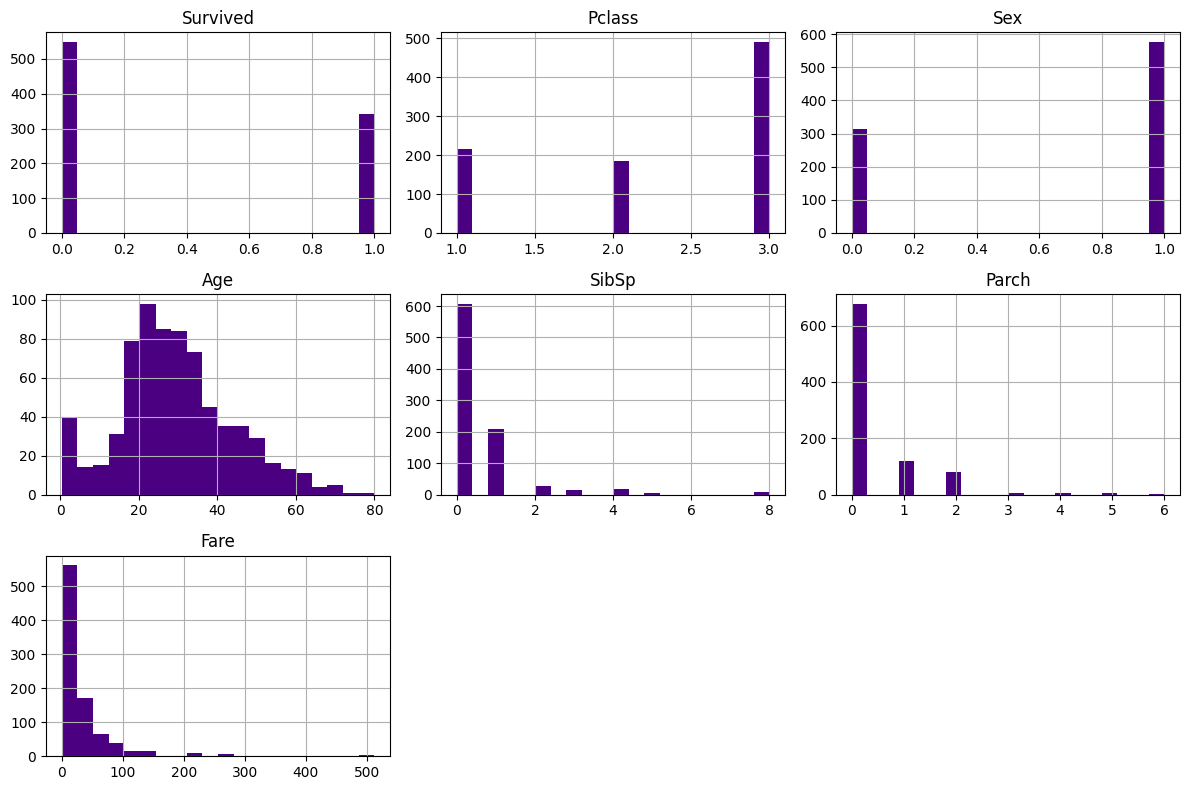

In [143]:
eda_data[features].hist(bins=20, figsize=(12,8), color='indigo')
plt.tight_layout()
plt.show()

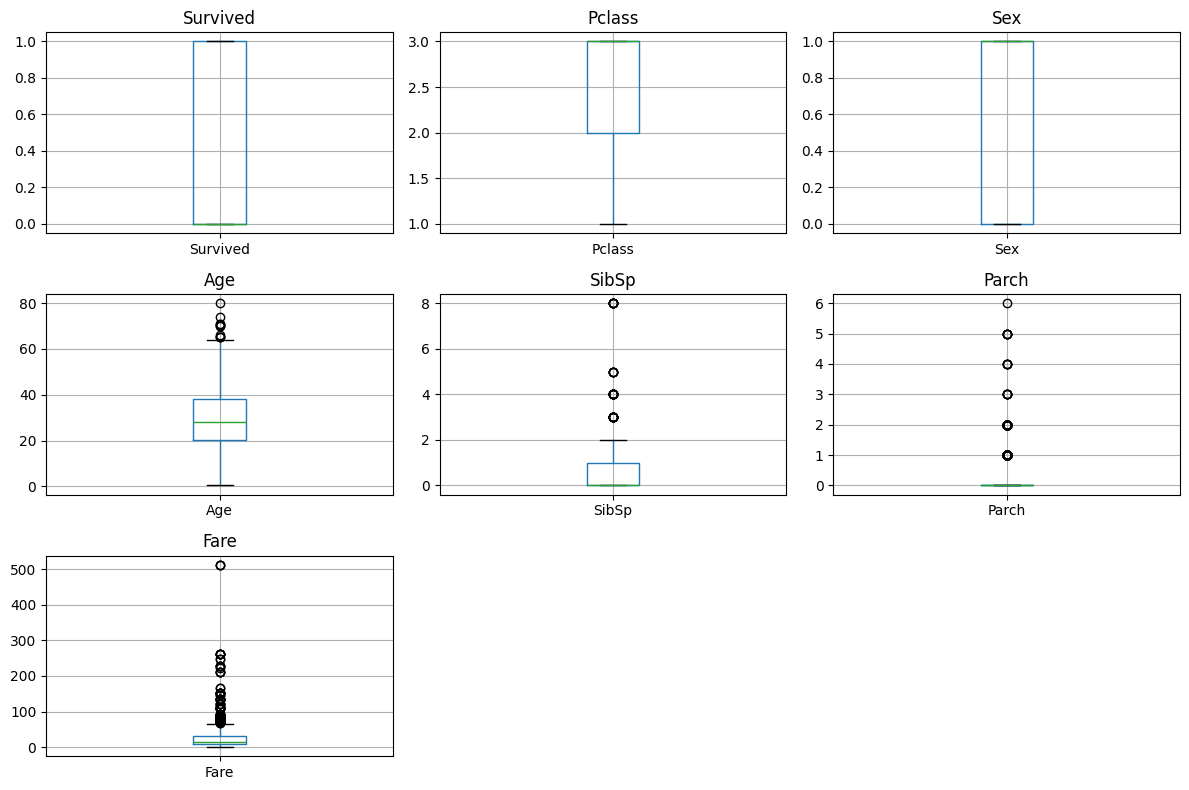

In [144]:
# Boxplot for numerical features to check for outliers and distribution
plt.figure(figsize=(12,8))

for i,col in enumerate(features):
    plt.subplot(3,3, i+1)
    eda_data.boxplot(column=col)
    plt.title(col)
    
plt.tight_layout()
plt.show()

<Axes: xlabel='Survived', ylabel='Age'>

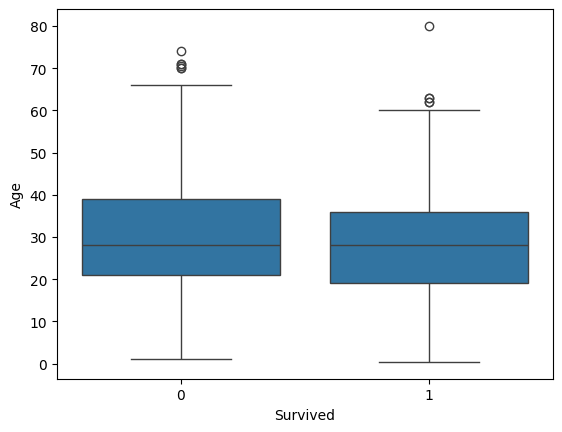

In [145]:
sb.boxplot(x='Survived', y='Age', data=eda_data)

<Axes: xlabel='Survived', ylabel='Fare'>

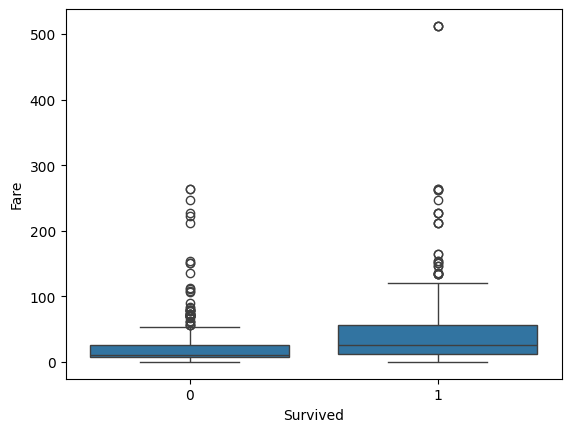

In [146]:
sb.boxplot(x='Survived', y='Fare', data=eda_data)

In [147]:
eda_data['Sex'].unique()

array([1, 0])

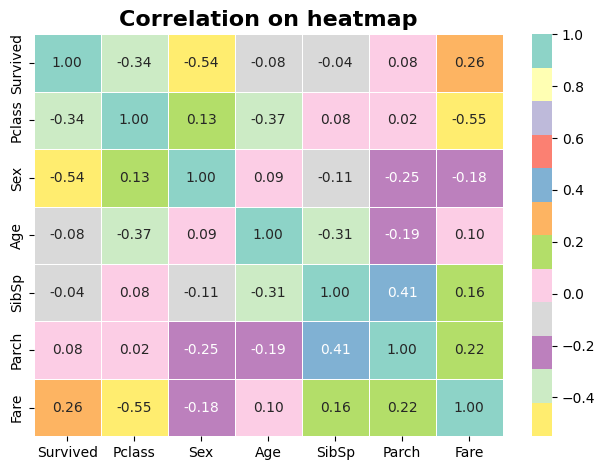

In [148]:
cor1 = eda_data[features].corr(method='pearson')
sb.heatmap(cor1, annot=True, cmap='Set3_r', linewidths=0.5, fmt='.2f')
plt.title('Correlation on heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

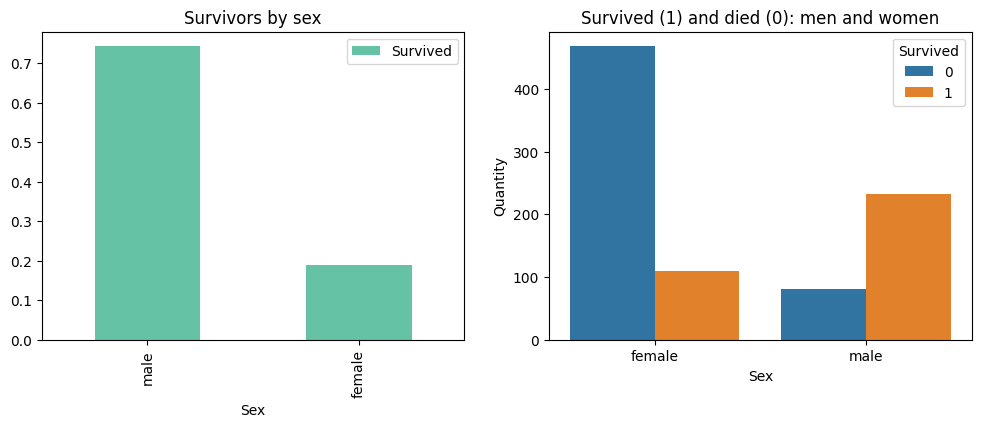

Sex
Male      74.203822
Female    18.890815
Name: Survived, dtype: float64


In [149]:
f, ax = plt.subplots(1, 2, figsize=(12, 4)) 
label_map = {0: "male", 1: "female"}
eda_data[['Sex', 'Survived']].groupby(['Sex']).mean().rename(index=label_map).plot.bar(ax=ax[0], colormap='Set2') 
ax[0].set_title('Survivors by sex') 

sb.countplot(x=eda_data['Sex'].map(label_map), hue='Survived', data=eda_data, ax=ax[1])
ax[1].set_ylabel('Quantity') 
ax[1].set_title('Survived (1) and died (0): men and women') 
plt.show()

label_map={0: 'Male', 1: 'Female'}
sex_survival = eda_data.groupby('Sex')['Survived'].mean().rename(index=label_map) * 100
print(sex_survival)

In [150]:
sex_counts = eda_data['Sex'].value_counts()
print(sex_counts)

Sex
1    577
0    314
Name: count, dtype: int64


In [151]:
label_map={1: 'Class 1', 2: 'Class 2', 3:'Class 3'}
pclass_survival = (eda_data.groupby('Pclass')['Survived'].mean() * 100).round(2).rename(index=label_map)
print(pclass_survival)

Pclass
Class 1    62.96
Class 2    47.28
Class 3    24.24
Name: Survived, dtype: float64


In [152]:
pclass_counts = eda_data['Pclass'].value_counts()
print(pclass_counts)

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


In [153]:
embarked_counts = eda_data['Embarked'].value_counts()
print(embarked_counts)

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


Survived  Survived  Died
Pclass                  
1               80   136
2               97    87
3              372   119


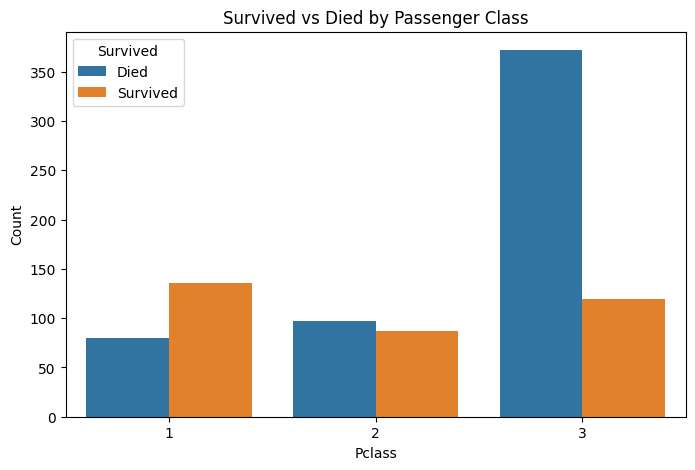

In [154]:
label_map = {1: 'Died', 0: 'Survived'}

# Keep Pclass index unchanged (1,2,3), only rename Survived labels
summary = (
    eda_data.groupby(['Pclass', 'Survived'])
    .size()
    .unstack(fill_value=0)
    .rename(columns=label_map)
)
print(summary)

plt.figure(figsize=(8, 5))
sb.countplot(
    data=eda_data,
    x='Pclass',
    hue='Survived',
    order=[1, 2, 3],
    hue_order=[0, 1]
)

plt.title("Survived vs Died by Passenger Class")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.xticks([0, 1, 2], ['1', '2', '3'])
plt.legend(title='Survived', labels=['Died', 'Survived'])
plt.show()

In [155]:
# Create AgeGroup column based on Age with specified age ranges and handle missing values as 'Unknown' 
# Result showing the survival rate by age group and class
eda_data['AgeGroup'] = eda_data['Age'].apply(
    lambda age: "Child" if age < 13 else
                "Teen" if age < 18 else
                "Young Adult" if age < 30 else
                "Adult" if age < 60 else
                "Senior"
    if pd.notnull(age) else "Unknown"
)

age_survival = (eda_data.groupby('AgeGroup')['Survived'].mean() * 100).round(1).sort_values(ascending=False)
print(age_survival)

AgeGroup
Child          58.0
Teen           47.7
Adult          41.8
Young Adult    35.1
Unknown        29.4
Senior         26.9
Name: Survived, dtype: float64


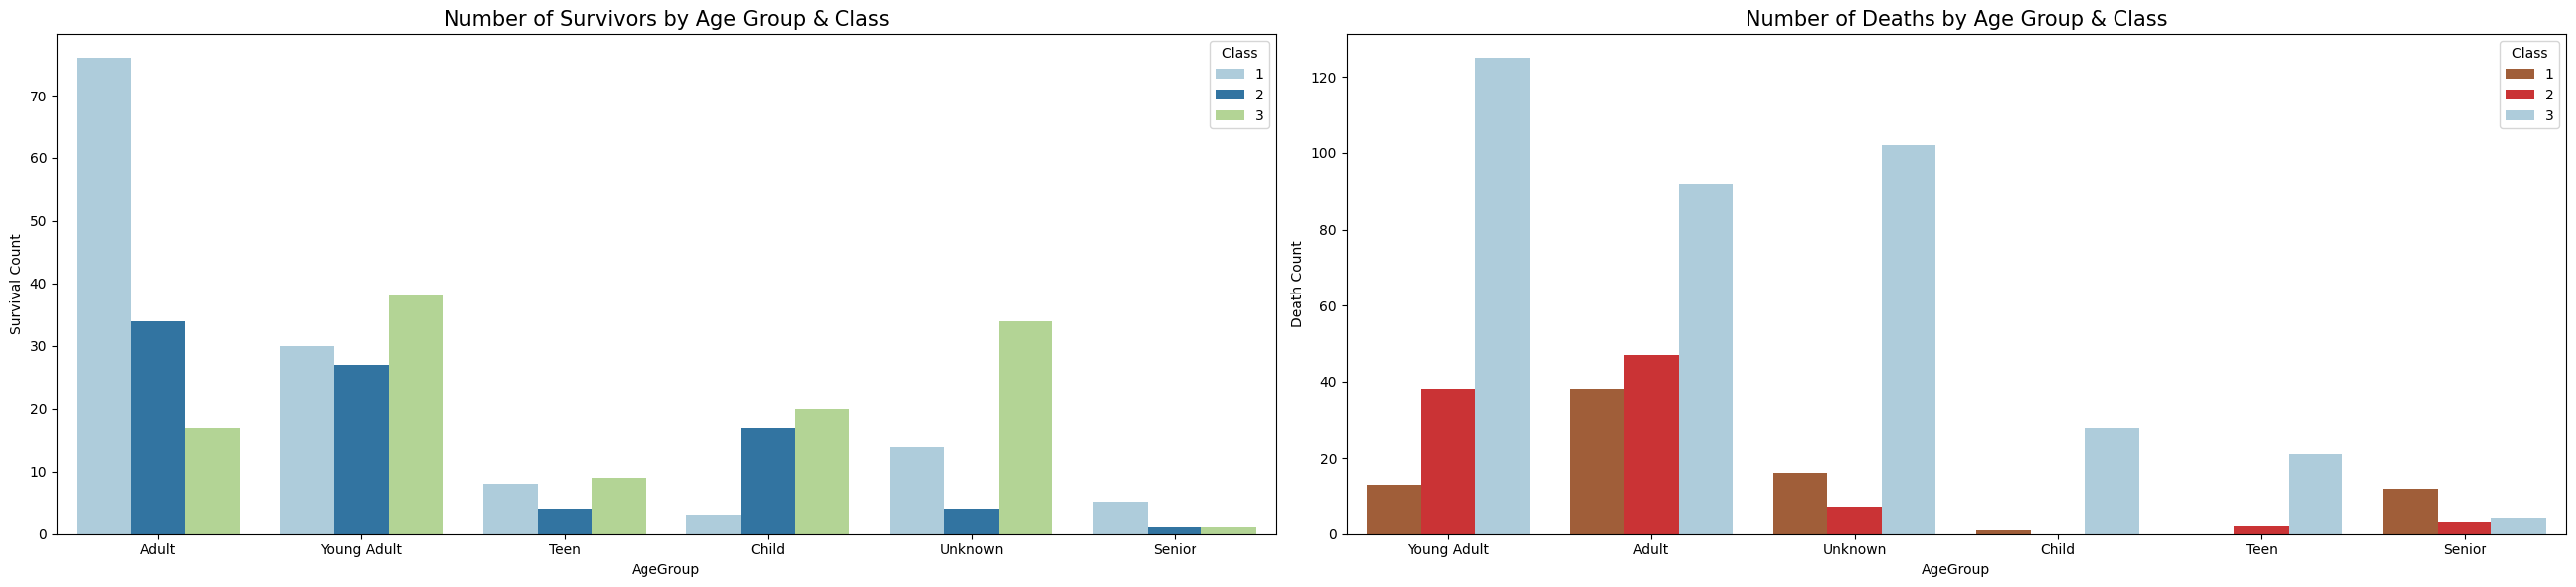

In [156]:
died_df = eda_data[eda_data['Survived'] == 0]
survived_df = eda_data[eda_data['Survived'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(26, 6))

# 3) Survival Count
# Ensure axes[2] exists (maps to the first subplot in a 1x2 layout)
if len(axes) == 2:
    axes = np.array([axes[0], axes[1], axes[0]], dtype=object)

sb.countplot(
    data=survived_df,
    x='AgeGroup',
    hue='Pclass',
    palette='Paired',
    ax=axes[2]
)
axes[2].set_title("Number of Survivors by Age Group & Class", fontsize=15)
axes[2].set_ylabel("Survival Count")
axes[2].legend(title="Class")

# 2) Death Count
sb.countplot(
    data=died_df,
    x='AgeGroup',
    hue='Pclass',
    palette='Paired_r',
    ax=axes[1]
)
axes[1].set_title("Number of Deaths by Age Group & Class", fontsize=15)
axes[1].set_ylabel("Death Count")
axes[1].legend(title="Class")

plt.tight_layout()

plt.show()

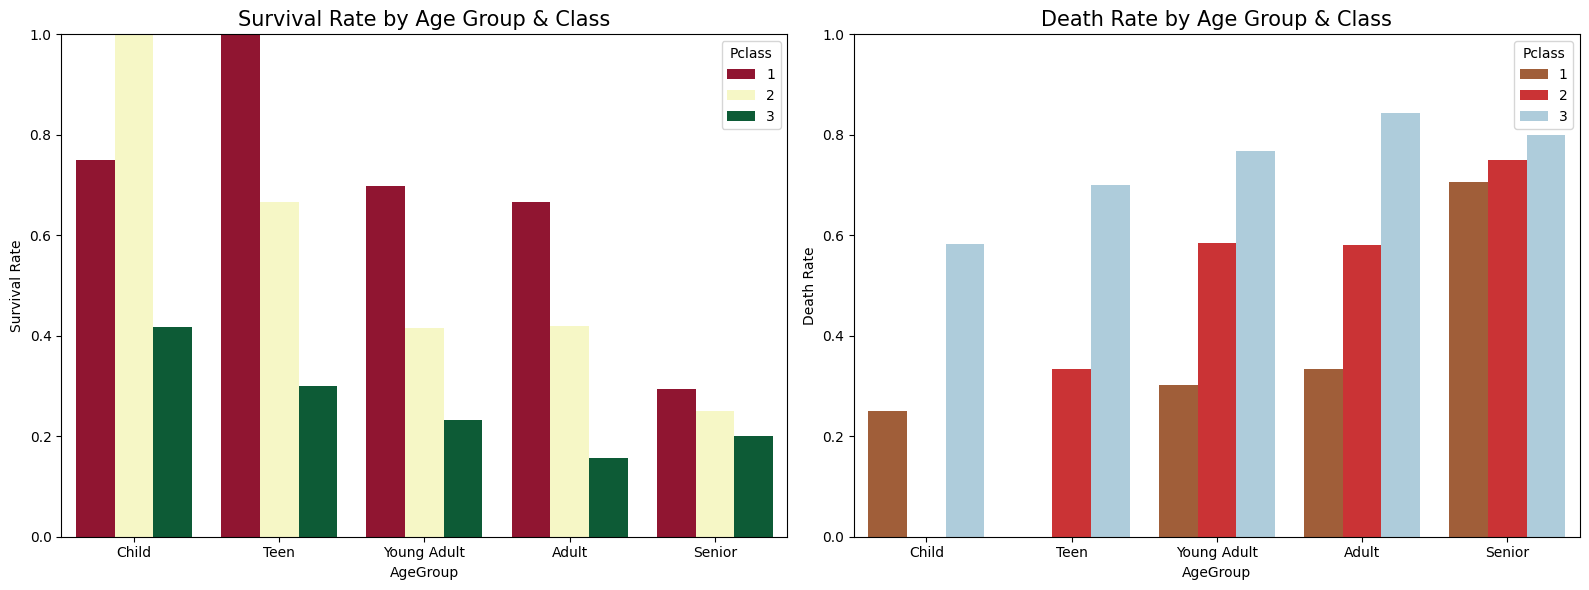

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = eda_data.copy()
plot_df['Death'] = 1 - plot_df['Survived']

age_order = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

# 1) Survival Rate
sb.barplot(
    data=plot_df,
    x='AgeGroup',
    y='Survived',
    hue='Pclass',
    order=age_order,
    palette='RdYlGn',
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Survival Rate by Age Group & Class", fontsize=15)
axes[0].set_ylabel("Survival Rate")
axes[0].set_ylim(0, 1)

# 2) Death Rate
sb.barplot(
    data=plot_df,
    x='AgeGroup',
    y='Death',
    hue='Pclass',
    order=age_order,
    palette='Paired_r',
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Death Rate by Age Group & Class", fontsize=15)
axes[1].set_ylabel("Death Rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [158]:
eda_data.groupby(['Pclass','AgeGroup'])['Survived'].value_counts()

Pclass  AgeGroup     Survived
1       Adult        1            76
                     0            38
        Child        1             3
                     0             1
        Senior       0            12
                     1             5
        Teen         1             8
        Unknown      0            16
                     1            14
        Young Adult  1            30
                     0            13
2       Adult        0            47
                     1            34
        Child        1            17
        Senior       0             3
                     1             1
        Teen         1             4
                     0             2
        Unknown      0             7
                     1             4
        Young Adult  0            38
                     1            27
3       Adult        0            92
                     1            17
        Child        0            28
                     1            20
        

Embarked
C    55.36
Q    38.96
S    33.90
Name: Survived, dtype: float64


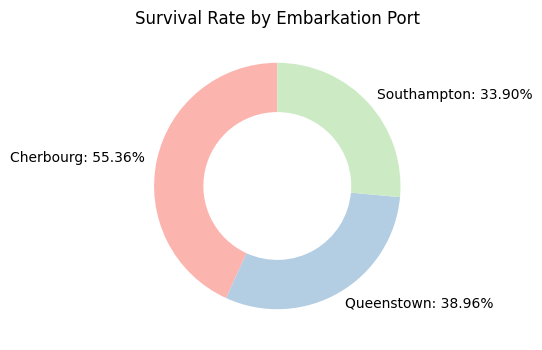

In [159]:
embarked_survival = eda_data.groupby('Embarked')['Survived'].mean() * 100
embarked_survival = embarked_survival.round(2)
print(embarked_survival)

name_map = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
labels = [f"{name_map[idx]}: {val:.2f}%" 
          for idx, val in embarked_survival.items()]

cmap = plt.get_cmap('Pastel1')
colors = [cmap(i) for i in range(len(embarked_survival))]

plt.figure(figsize=(18,4))
plt.pie(
    embarked_survival, 
    labels=labels, 
    colors=colors,
    wedgeprops={'width':0.4},
    startangle=90)
plt.title("Survival Rate by Embarkation Port")
plt.show()

In [160]:
# Summarize counts
summary = eda_data.groupby(['Pclass', 'AgeGroup']).size().unstack(fill_value=0)
summary

AgeGroup,Adult,Child,Senior,Teen,Unknown,Young Adult
Pclass,,,,,,
1,114,4,17,8,30,43
2,81,17,4,6,11,65
3,109,48,5,30,136,163


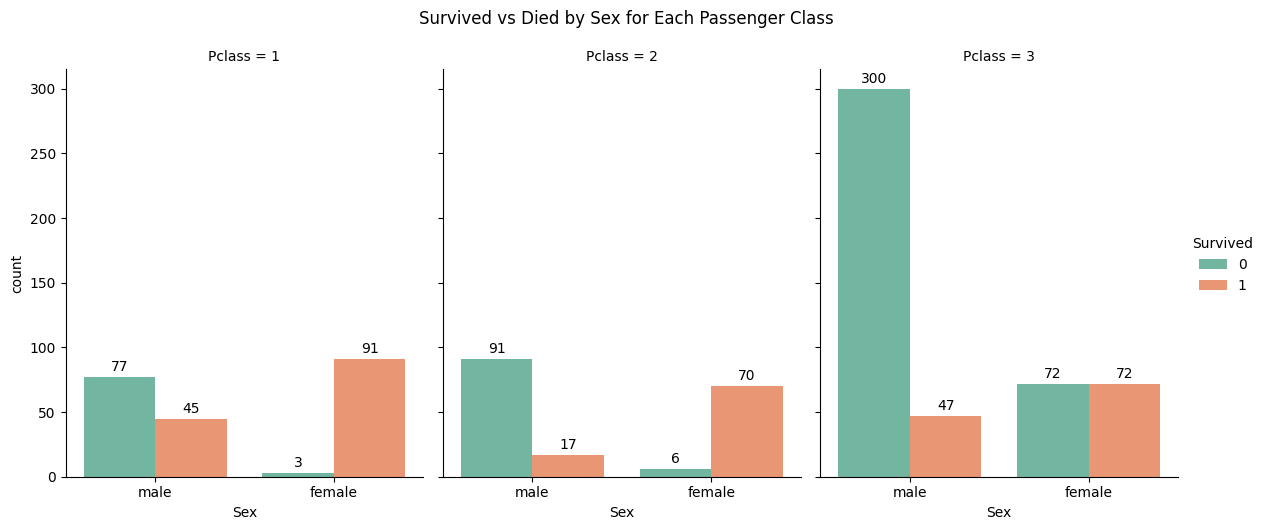

In [161]:
# map only if Sex is still numeric (avoid converting existing 'male'/'female' to NaN)
if pd.api.types.is_numeric_dtype(eda_data['Sex']):
    eda_data['Sex'] = eda_data['Sex'].map({0: 'female', 1: 'male'})

g = sb.catplot(
    data=eda_data,
    x='Sex',
    hue='Survived',
    col='Pclass',
    kind='count',
    palette='Set2',
    height=5,
    aspect=0.8
)

# labels on top of bars
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=2)

g.fig.suptitle("Survived vs Died by Sex for Each Passenger Class", y=1.05)
plt.show()


In [162]:
eda_data['FamilySize'] = eda_data['SibSp'] + eda_data['Parch'] + 1
family_survival = eda_data.groupby('FamilySize')['Survived'].mean() * 100
family_counts = eda_data['FamilySize'].value_counts().sort_index()

family_summary = pd.DataFrame({
    'PassengerCount': family_counts,
    'SurvivalRate(%)': family_survival
})

family_summary_sorted = family_summary.sort_values(by='SurvivalRate(%)', ascending=False)

print("Survival rate by family size:")
print(family_summary_sorted)


Survival rate by family size:
            PassengerCount  SurvivalRate(%)
FamilySize                                 
4                       29        72.413793
3                      102        57.843137
2                      161        55.279503
7                       12        33.333333
1                      537        30.353818
5                       15        20.000000
6                       22        13.636364
8                        6         0.000000
11                       7         0.000000


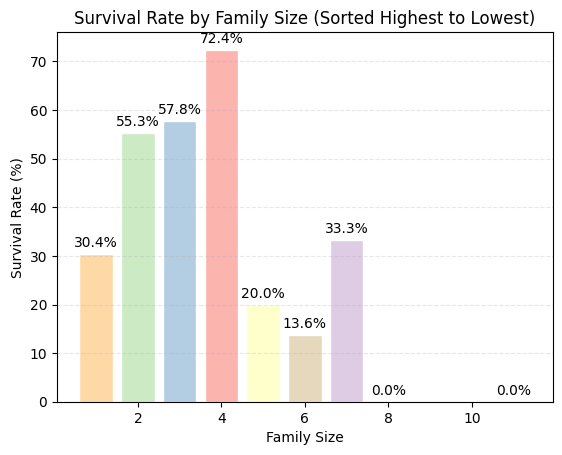

In [163]:
cmap = plt.get_cmap('Pastel1')
colors = cmap(np.linspace(0, 1, len(family_summary_sorted)))

bars = plt.bar(
    family_summary_sorted.index,
    family_summary_sorted['SurvivalRate(%)'],
    color=colors,
    edgecolor='white'
)

plt.xlabel('Family Size')
plt.ylabel('Survival Rate (%)')
plt.title("Survival Rate by Family Size (Sorted Highest to Lowest)")

# labels on top of bars
plt.bar_label(bars, fmt='%.1f%%', padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

**Why sibsp and parch are important for survival analysis?**
- Because they can indicate the presence of family members, which may have influenced a passenger's chances of survival. 
- For example, passengers with more family members aboard may have had a higher likelihood of being rescued together, while those traveling alone may have been at greater risk. 
- Additionally, the presence of family members could have affected a passenger's behavior during the evacuation, such as prioritizing the safety of loved ones over their own. 
- Therefore, analyzing SibSp and Parch can provide insights into the social dynamics and survival patterns of passengers on the Titanic.

In [164]:
Sibp_survival = eda_data.groupby('SibSp')['Survived'].mean() * 100
Sibp_survival = Sibp_survival.round(2)

SibSp_counts = eda_data['SibSp'].value_counts().sort_index()
SibSp_summary = pd.DataFrame({
    'PassengerCount': SibSp_counts,
    'SurvivalRate(%)': Sibp_survival
})
SibSp_summary_sorted = SibSp_summary.sort_values(by='SurvivalRate(%)', ascending=False)
print("Survival rate by number of siblings/spouses aboard:")
print(SibSp_summary_sorted)

Survival rate by number of siblings/spouses aboard:
       PassengerCount  SurvivalRate(%)
SibSp                                 
1                 209            53.59
2                  28            46.43
0                 608            34.54
3                  16            25.00
4                  18            16.67
5                   5             0.00
8                   7             0.00


In [165]:
Cabin_counts = eda_data['Cabin'].value_counts()
print("Cabin counts:")
print(Cabin_counts)

Cabin counts:
Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64


In [166]:
#which cabin class belong to which pclass
#show pclass first and then cabin deck in table format
pclass_cabin_table = eda_data.groupby(
    ['Pclass', eda_data['Cabin'].str[0]]
).size().unstack(fill_value=0)

print("Passenger count by Pclass and Cabin Deck:")
print(pclass_cabin_table)

Passenger count by Pclass and Cabin Deck:
Cabin    A   B   C   D   E  F  G  T
Pclass                             
1       15  47  59  29  25  0  0  1
2        0   0   0   4   4  8  0  0
3        0   0   0   0   3  5  4  0


In [167]:
# extract deck temporarily
deck = eda_data['Cabin'].str[0]

# passenger count by deck
deck_counts = deck.value_counts().sort_index().rename_axis('Deck')

# survival rate by deck
deck_survival = (eda_data.groupby(deck)['Survived'].mean() * 100).round(2)

deck_summary = pd.DataFrame({
    'PassengerCount': deck_counts,
    'SurvivalRate(%)': deck_survival
})

deck_summary_sorted = deck_summary.sort_values(by='SurvivalRate(%)', ascending=False)

print("Survival rate by Cabin Deck:")
print(deck_summary_sorted)

Survival rate by Cabin Deck:
   PassengerCount  SurvivalRate(%)
D              33            75.76
E              32            75.00
B              47            74.47
F              13            61.54
C              59            59.32
G               4            50.00
A              15            46.67
T               1             0.00


*interpretation of cabin deck and pclass*
- Deck A and B are mostly first class, 
- Deck C is mostly first class but also some second class, 
- Deck D is mostly second class but also some first class, 
- Deck E is mostly third class but also some second class, 
- Deck F and G are mostly third class, and 
- Deck T is mostly first class. 

_This suggests that higher class passengers were more likely to be assigned cabins on the upper decks, while lower class passengers were more likely to be assigned cabins on the lower decks._

_The survival rates by cabin deck also reflect this pattern, with higher survival rates for passengers in Decks A and B, and lower survival rates for passengers in Decks F and G._

## *Machine Learning Part* ##

#### Filling Missing Values in `Age` with normalization

In [168]:
## 1. Fill missing values in 'Embarked' column with the most common embarkation port 'S' (Southampton) based on the analysis of missing values and fare distribution by embarkation port.
ml_data['Embarked'] = ml_data['Embarked'].fillna('S')
test_data['Embarked'] = test_data['Embarked'].fillna('S')

test_data['Sex'] = test_data['Sex'].map({1: 'male', 0: 'female'})

## 2. Creating mean age table from Train dataset and apply to both train and test dataset
age_mean_table = ml_data.groupby(['Sex','Pclass','Embarked'])['Age'].mean().round(0)

for i in ml_data.index:
    if pd.isna(ml_data.loc[i,'Age']):
        sex = ml_data.loc[i,'Sex']
        pclass = ml_data.loc[i,'Pclass']
        embarked = ml_data.loc[i,'Embarked']

        if (sex,pclass,embarked) in age_mean_table.index:
            ml_data.loc[i,'Age'] = age_mean_table.loc[(sex,pclass,embarked)]


for i in test_data.index:
    if pd.isna(test_data.loc[i,'Age']):
        sex = test_data.loc[i,'Sex']
        pclass = test_data.loc[i,'Pclass']
        embarked = test_data.loc[i,'Embarked']

        if (sex,pclass,embarked) in age_mean_table.index:
            test_data.loc[i,'Age'] = age_mean_table.loc[(sex,pclass,embarked)]

## fall back to overall median age if any Age is still missing after the group-based imputation
ml_data['Age'] = ml_data['Age'].fillna(ml_data['Age'].median())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())
            
# 3. Fill missing values in 'Fare' column of test dataset with the median fare of passengers in the same Pclass and Embarked group based on the analysis of missing values and fare distribution by class and embarkation port.
test_data['Fare'] = test_data['Fare'].fillna(test_data.groupby(['Pclass', 'Embarked'])['Fare'].transform('median'))

<Axes: >

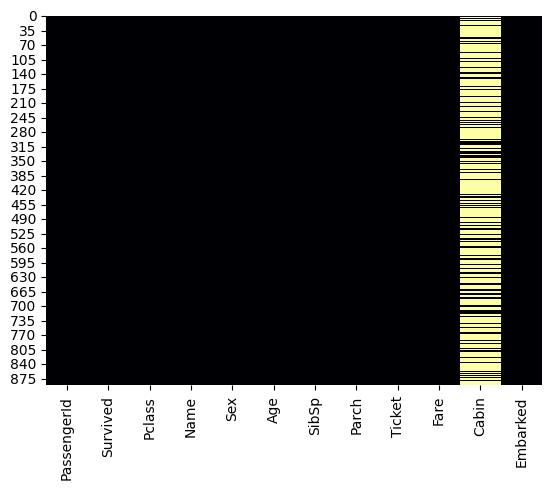

In [169]:
sb.heatmap(ml_data.isnull(), cbar=False, cmap='inferno')

<Axes: >

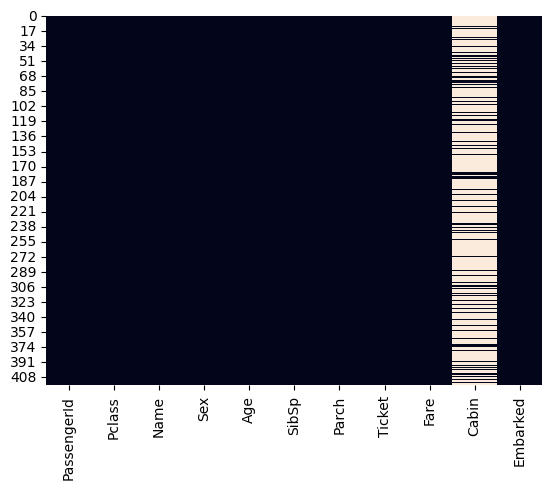

In [170]:
sb.heatmap(test_data.isnull(), cbar=False)

In [171]:
print(ml_data['Sex'].unique())
print(test_data['Sex'].unique())
print(ml_data['Embarked'].unique())
print(test_data['Embarked'].unique())

['male' 'female']
['male' 'female']
['S' 'C' 'Q']
['Q' 'S' 'C']


In [172]:
ml_data['Sex'] = ml_data['Sex'].map({'male': 1, 'female': 0})
test_data['Sex'] = test_data['Sex'].map({'male': 1, 'female': 0})

ml_data['Embarked'] = ml_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test_data['Embarked'] = test_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


In [173]:
print(ml_data['Sex'].unique())
print(test_data['Sex'].unique())
print(ml_data['Embarked'].unique())
print(test_data['Embarked'].unique())

[1 0]
[1 0]
[0 1 2]
[2 0 1]


## Feature Importances 

In [174]:
#Feature Importances and permutation importance analysis for the features in the train dataset using Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score


features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
# Prepare the data for modeling
x = ml_data[features]
y = ml_data['Survived']

# Split the data into training and validation sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
print("Random Forest Classifier Performance:", accuracy_score(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Random Forest Recall:", recall_score(y_test, rf_pred))
print("Random Forest Precision:", precision_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

print("=" * 50 + "\n")

# Train a xgboost Classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(x_test)
print("XGBoost Classifier Performance:", accuracy_score(y_test, xgb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))
print("XGBoost Recall:", recall_score(y_test, xgb_pred))
print("XGBoost Precision:", precision_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Random Forest Classifier Performance: 0.8268156424581006
Confusion Matrix:
 [[91 14]
 [17 57]]
Random Forest Recall: 0.7702702702702703
Random Forest Precision: 0.8028169014084507
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179


XGBoost Classifier Performance: 0.8435754189944135
Confusion Matrix:
 [[91 14]
 [14 60]]
XGBoost Recall: 0.8108108108108109
XGBoost Precision: 0.8108108108108109
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       105
           1       0.81      0.81      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.84      0.84      0.84       179



In [175]:
# Compare XGBoost results for different max_depth values
depth_results = []

for depth in [3, 4, 5, 6]:
    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=depth,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    
    depth_results.append({
        'max_depth': depth,
        'accuracy': accuracy_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'precision': precision_score(y_test, preds)
    })

depth_results_df = pd.DataFrame(depth_results).sort_values(by='accuracy', ascending=False)
print(depth_results_df.round(4))

   max_depth  accuracy  recall  precision
1          4    0.8492  0.8108     0.8219
3          6    0.8492  0.7973     0.8310
2          5    0.8436  0.8108     0.8108
0          3    0.8212  0.7297     0.8182


In [176]:
# Train a xgboost Classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(x_test)
print("XGBoost Classifier Performance:", accuracy_score(y_test, xgb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))
print("XGBoost Recall:", recall_score(y_test, xgb_pred))
print("XGBoost Precision:", precision_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Classifier Performance: 0.8491620111731844
Confusion Matrix:
 [[93 12]
 [15 59]]
XGBoost Recall: 0.7972972972972973
XGBoost Precision: 0.8309859154929577
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       105
           1       0.83      0.80      0.81        74

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



**_Random Forest Feature Importance_**

    Feature  Importance
5      Fare        0.27
1       Sex        0.26
2       Age        0.25
0    Pclass        0.09
3     SibSp        0.05
4     Parch        0.04
6  Embarked        0.03
--------------------------------------------------



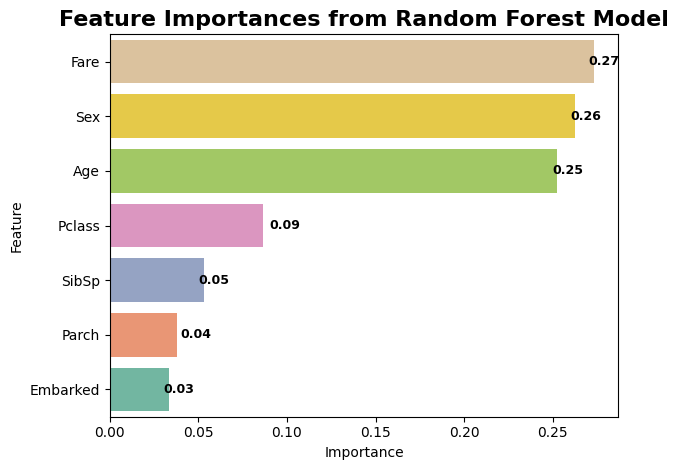

In [177]:
# Get feature importances from the Random Forest model
rf_importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='Set2', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from Random Forest Model", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

    Feature  Importance
1       Sex        0.53
0    Pclass        0.16
3     SibSp        0.07
5      Fare        0.07
2       Age        0.06
4     Parch        0.06
6  Embarked        0.05
--------------------------------------------------



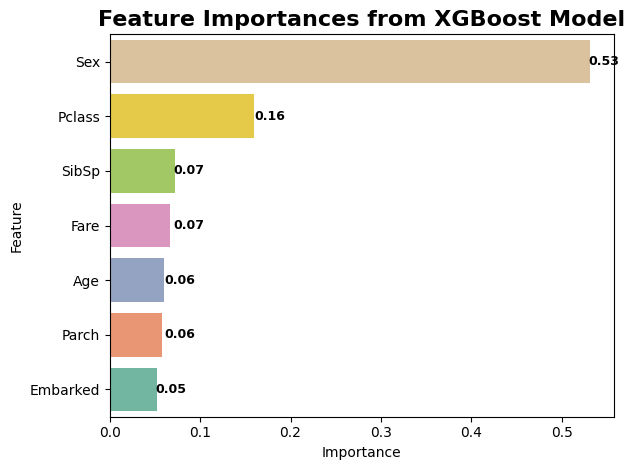

In [178]:
# Get feature importances from the XGBoost model
xgb_importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='Set2', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from XGBoost Model", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

    Feature  Importance
1       Sex        0.18
0    Pclass        0.07
5      Fare        0.06
6  Embarked        0.03
2       Age        0.03
3     SibSp        0.01
4     Parch        0.01
--------------------------------------------------



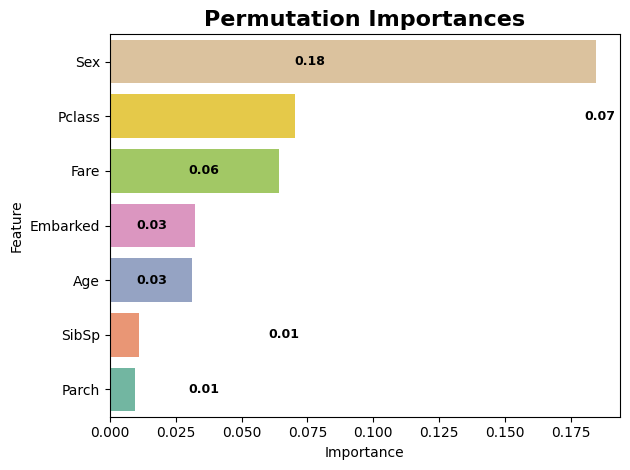

In [179]:
# Permutation importance
perm_importance_rf= permutation_importance(rf_model, x_test, y_test, n_repeats=10, random_state=42)
perm_importance_rf_df = pd.DataFrame({
    'Feature': features,
    'Importance': perm_importance_rf.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_rf_df.round(2))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
sb.barplot(x='Importance', y='Feature', data=perm_importance_rf_df, palette='Set2', hue='Importance', legend=False)
labels = perm_importance_rf_df['Importance'].round(2).astype(str)
for index, value in enumerate(perm_importance_rf.importances_mean.round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Permutation Importances", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


    Feature  Importance
1       Sex        0.16
0    Pclass        0.07
2       Age        0.07
5      Fare        0.03
6  Embarked        0.03
3     SibSp        0.01
4     Parch        0.01
--------------------------------------------------



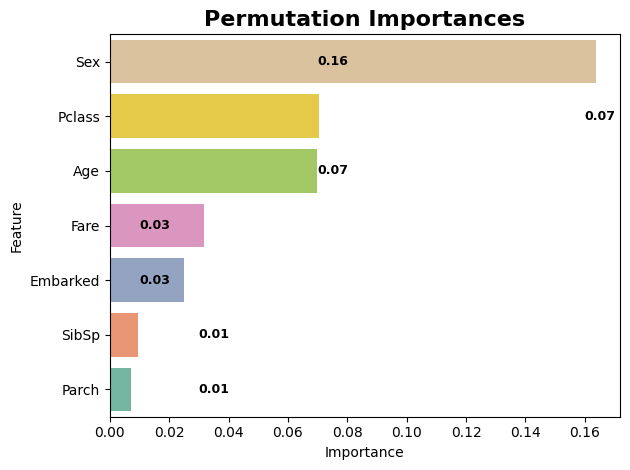

In [180]:
# Permutation importance with XGBoost model
perm_importance_xgb= permutation_importance(xgb_model, x_test, y_test, n_repeats=10, random_state=42)
perm_importance_xgb_df = pd.DataFrame({
    'Feature': features,
    'Importance': perm_importance_xgb.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_xgb_df.round(2))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
sb.barplot(x='Importance', y='Feature', data=perm_importance_xgb_df, palette='Set2', hue='Importance', legend=False)
labels = perm_importance_xgb_df['Importance'].round(2).astype(str)
for index, value in enumerate(perm_importance_xgb.importances_mean.round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Permutation Importances", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [181]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Cross-validation for Random Forest
rf_cv_scores = cross_val_score(rf_model, x, y, cv=5)
print("Random Forest Cross-Validation Scores:", rf_cv_scores.mean().round(3))
print("Random Forest CV Mean Accuracy:", rf_cv_scores.mean().round(3))
print("Random Forest Std:", rf_cv_scores.std().round(3))
print("=" * 50 + "\n")
# Cross-validation for XGBoost
xgb_cv_scores = cross_val_score(xgb_model, x, y, cv=5)
print("XGBoost Cross-Validation Scores:", xgb_cv_scores.mean().round(3))
print("XGBoost CV Mean Accuracy:", xgb_cv_scores.mean().round(3))
print("XGBoost Std:", xgb_cv_scores.std().round(3))
print("=" * 50 + "\n")

#------------------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_stratified_scores = cross_val_score(rf_model, x, y, cv=skf, scoring='recall')
print("Random Forest Stratified CV Scores:", rf_stratified_scores.mean().round(3))
print("Random Forest Stratified CV Mean Accuracy:", rf_stratified_scores.mean().round(3))
print("Random Forest Stratified CV Std:", rf_stratified_scores.std().round(3))
print("=" * 50 + "\n")

xgb_stratified_scores = cross_val_score(xgb_model, x, y, cv=skf, scoring='recall')
print("XGBoost Stratified CV Scores:", xgb_stratified_scores.mean().round(3))
print("XGBoost Stratified CV Mean Accuracy:", xgb_stratified_scores.mean().round(3))
print("XGBoost Stratified CV Std:", xgb_stratified_scores.std().round(3))


Random Forest Cross-Validation Scores: 0.808
Random Forest CV Mean Accuracy: 0.808
Random Forest Std: 0.03

XGBoost Cross-Validation Scores: 0.836
XGBoost CV Mean Accuracy: 0.836
XGBoost Std: 0.029

Random Forest Stratified CV Scores: 0.757
Random Forest Stratified CV Mean Accuracy: 0.757
Random Forest Stratified CV Std: 0.022

XGBoost Stratified CV Scores: 0.751
XGBoost Stratified CV Mean Accuracy: 0.751
XGBoost Stratified CV Std: 0.019


## Improve Accuracy by adding Title analysis into new Features

In [182]:
ml_data['Ttitle'] = ml_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test_data['Ttitle'] = test_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(ml_data['Ttitle'].value_counts())
print("-" * 50 + "\n")
print(test_data['Ttitle'].value_counts())

Ttitle
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64
--------------------------------------------------

Ttitle
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64


In [183]:
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Mme', 'Ms', 'Mlle', 'Lady', 'Sir', 'Capt', 'Countess', 'Jonkheer', 'Don', 'Dona']

ml_data['Ttitle'] = ml_data['Ttitle'].replace(rare_titles, 'Rare')
test_data['Ttitle'] = test_data['Ttitle'].replace(rare_titles, 'Rare')
print(ml_data['Ttitle'].value_counts())


Ttitle
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [184]:
#Convert title to numbers
title_mapping = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}
ml_data['Ttitle'] = ml_data['Ttitle'].map(title_mapping)
test_data['Ttitle'] = test_data['Ttitle'].map(title_mapping)
print(ml_data['Ttitle'].unique())
print(test_data['Ttitle'].unique())

[0 2 1 3 4]
[0 2 1 3 4]


In [185]:
new_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Ttitle']

In [186]:
x1 = ml_data[new_features]
y1 = ml_data['Survived']

x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=42) 

In [187]:
# new_features and Train a Random Forest Classifier
rf_model2 = RandomForestClassifier(
    n_estimators=150,
    random_state=42)
rf_model2.fit(x1_train, y1_train)

rf_pred2 = rf_model2.predict(x1_test)
print("Random Forest Classifier Performance:", accuracy_score(y1_test, rf_pred2))
print("Confusion Matrix:\n", confusion_matrix(y1_test, rf_pred2))
print("Random Forest Recall:", recall_score(y1_test, rf_pred2))
print("Random Forest Precision:", precision_score(y1_test, rf_pred2))
print(classification_report(y1_test, rf_pred2))

print("=" * 50 + "\n")

# Train a xgboost Classifier
xgb_model2 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
xgb_model2.fit(x1_train, y1_train)
xgb_pred2 = xgb_model2.predict(x1_test)
print("XGBoost Classifier Performance:", accuracy_score(y1_test, xgb_pred2))
print("Confusion Matrix:\n", confusion_matrix(y1_test, xgb_pred2))
print("XGBoost Recall:", recall_score(y1_test, xgb_pred2))
print("XGBoost Precision:", precision_score(y1_test, xgb_pred2))
print(classification_report(y1_test, xgb_pred2))

Random Forest Classifier Performance: 0.8547486033519553
Confusion Matrix:
 [[91 14]
 [12 62]]
Random Forest Recall: 0.8378378378378378
Random Forest Precision: 0.8157894736842105
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       105
           1       0.82      0.84      0.83        74

    accuracy                           0.85       179
   macro avg       0.85      0.85      0.85       179
weighted avg       0.86      0.85      0.86       179


XGBoost Classifier Performance: 0.8491620111731844
Confusion Matrix:
 [[91 14]
 [13 61]]
XGBoost Recall: 0.8243243243243243
XGBoost Precision: 0.8133333333333334
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       105
           1       0.81      0.82      0.82        74

    accuracy                           0.85       179
   macro avg       0.84      0.85      0.84       179
weighted avg       0.85      0.85      0.85       179



    Feature  Importance
5      Fare        0.26
2       Age        0.22
7    Ttitle        0.17
1       Sex        0.15
0    Pclass        0.08
3     SibSp        0.06
4     Parch        0.03
6  Embarked        0.03
--------------------------------------------------



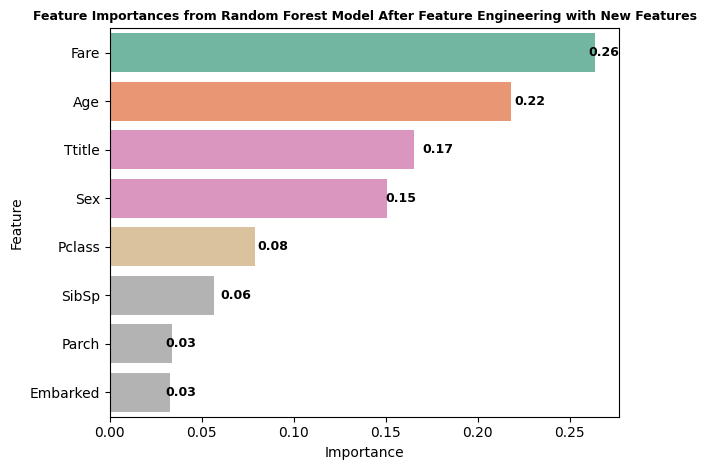

In [188]:
# Get feature importances from the Random Forest model
rf_importances2 = rf_model2.feature_importances_
feature_importance_df2 = pd.DataFrame({
    'Feature': new_features,
    'Importance': rf_importances2
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df2.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df2, palette='Set2_r', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df2['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df2['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from Random Forest Model After Feature Engineering with New Features", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

    Feature  Importance
7    Ttitle        0.39
1       Sex        0.19
0    Pclass        0.15
3     SibSp        0.07
5      Fare        0.06
4     Parch        0.05
2       Age        0.05
6  Embarked        0.05
--------------------------------------------------



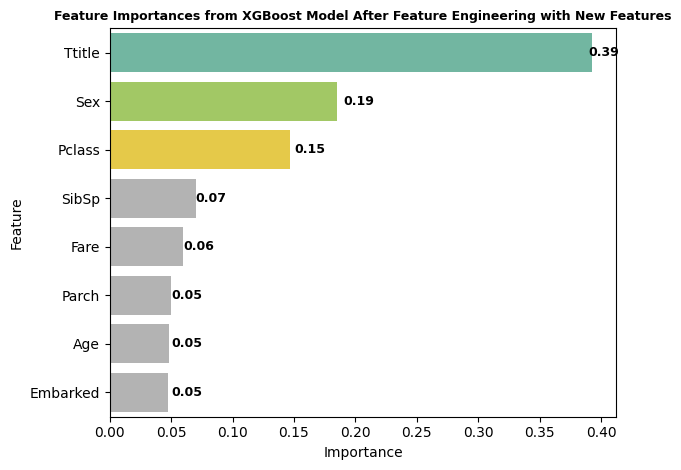

In [189]:
# Get feature importances from the XGBoost model
xgb_importances2 = xgb_model2.feature_importances_
feature_importance_df2 = pd.DataFrame({
    'Feature': new_features,
    'Importance': xgb_importances2
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df2.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df2, palette='Set2_r', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df2['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df2['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from XGBoost Model After Feature Engineering with New Features", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### Permutation importance with Random Forest and XGBoost models after feature engineering with new features

    Feature  Importance
5      Fare        0.07
1       Sex        0.06
0    Pclass        0.06
7    Ttitle        0.05
6  Embarked        0.04
2       Age        0.03
4     Parch        0.02
3     SibSp        0.02
--------------------------------------------------



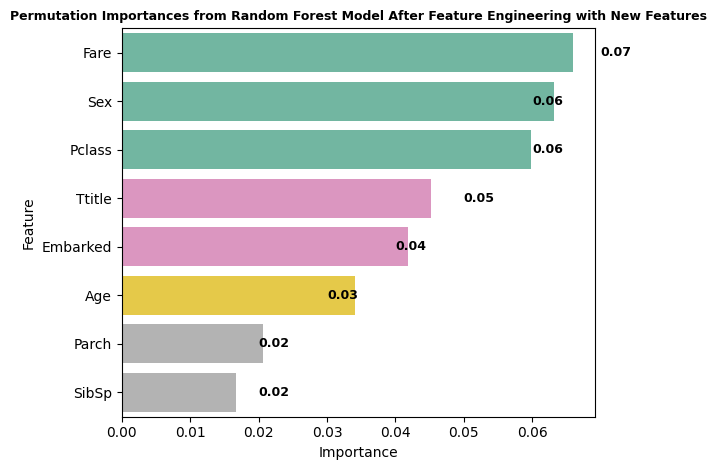

In [190]:
# Permutation importance with Random Forest model after feature engineering with new features
perm_importance_rf2= permutation_importance(rf_model2, x1_test, y1_test, n_repeats=10, random_state=42)
perm_importance_rf_df = pd.DataFrame({
    'Feature': new_features,
    'Importance': perm_importance_rf2.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_rf_df.round(2))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
ax = sb.barplot(
    x='Importance',
    y='Feature',
    data=perm_importance_rf_df,
    palette='Set2_r',
    hue='Importance',
    legend=False
)

labels = perm_importance_rf_df['Importance'].round(2).astype(str)
for index, value in enumerate(perm_importance_rf_df['Importance'].round(2)):
    ax.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')

plt.title("Permutation Importances from Random Forest Model After Feature Engineering with New Features", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


    Feature  Importance
7    Ttitle        0.12
0    Pclass        0.08
1       Sex        0.06
2       Age        0.05
5      Fare        0.05
6  Embarked        0.03
3     SibSp        0.01
4     Parch        0.01
--------------------------------------------------



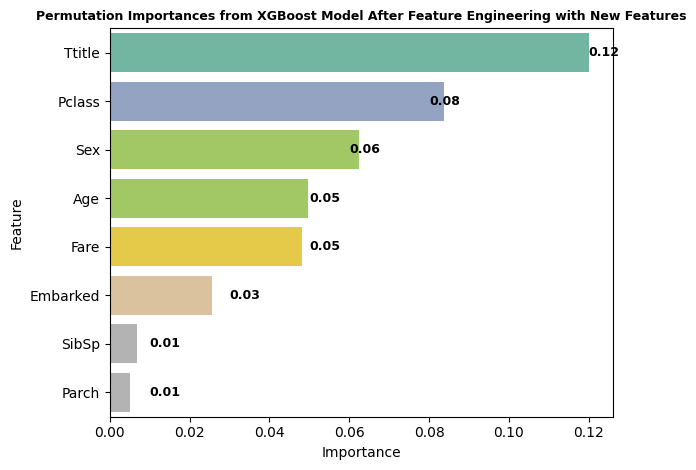

In [191]:
# Permutation importance with XGBoost model after feature engineering with new features
perm_importance_xgb2= permutation_importance(xgb_model2, x1_test, y1_test, n_repeats=10, random_state=42)
perm_importance_xgb_df2 = pd.DataFrame({
    'Feature': new_features,
    'Importance': perm_importance_xgb2.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_xgb_df2.round(2))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
ax = sb.barplot(
    x='Importance',
    y='Feature',
    data=perm_importance_xgb_df2,
    palette='Set2_r',
    hue='Importance',
    legend=False
)

labels = perm_importance_xgb_df2['Importance'].round(2).astype(str)
for index, value in enumerate(perm_importance_xgb_df2['Importance'].round(2)):
    ax.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')

plt.title("Permutation Importances from XGBoost Model After Feature Engineering with New Features", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [192]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Cross-validation for Random Forest
rf_cv_scores2 = cross_val_score(rf_model2, x1, y1, cv=5)
print("Random Forest Cross-Validation Scores:", rf_cv_scores2.mean().round(3))
print("Random Forest CV Mean Accuracy:", rf_cv_scores2.mean().round(3))
print("Random Forest Std:", rf_cv_scores2.std().round(3))
print("=" * 50 + "\n")
# Cross-validation for XGBoost
xgb_cv_scores2 = cross_val_score(xgb_model2, x1, y1, cv=5)
print("XGBoost Cross-Validation Scores:", xgb_cv_scores2.mean().round(3))
print("XGBoost CV Mean Accuracy:", xgb_cv_scores2.mean().round(3))
print("XGBoost Std:", xgb_cv_scores2.std().round(3))
print("=" * 50 + "\n")

#------------------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_stratified_scores2 = cross_val_score(rf_model2, x1, y1, cv=skf, scoring='recall')
print("Random Forest Stratified CV Scores:", rf_stratified_scores2.mean().round(3))
print("Random Forest Stratified CV Mean Accuracy:", rf_stratified_scores2.mean().round(3))
print("Random Forest Stratified CV Std:", rf_stratified_scores2.std().round(3))
print("=" * 50 + "\n")

xgb_stratified_scores2 = cross_val_score(xgb_model2, x1, y1, cv=skf, scoring='recall')
print("XGBoost Stratified CV Scores:", xgb_stratified_scores2.mean().round(3))
print("XGBoost Stratified CV Mean Accuracy:", xgb_stratified_scores2.mean().round(3))
print("XGBoost Stratified CV Std:", xgb_stratified_scores2.std().round(3))


Random Forest Cross-Validation Scores: 0.802
Random Forest CV Mean Accuracy: 0.802
Random Forest Std: 0.026

XGBoost Cross-Validation Scores: 0.835
XGBoost CV Mean Accuracy: 0.835
XGBoost Std: 0.018

Random Forest Stratified CV Scores: 0.746
Random Forest Stratified CV Mean Accuracy: 0.746
Random Forest Stratified CV Std: 0.021

XGBoost Stratified CV Scores: 0.766
XGBoost Stratified CV Mean Accuracy: 0.766
XGBoost Stratified CV Std: 0.025


### **_Testing by Adding `Cabin` into ML for accuracy improvement_**

In [193]:
ml_data['Deck'] = ml_data['Cabin'].str[0]
test_data['Deck'] = test_data['Cabin'].str[0]
ml_data['Deck'] = ml_data['Deck'].fillna('U')
test_data['Deck'] = test_data['Deck'].fillna('U')

In [194]:
deck_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'T': 7, 'U': 8}
ml_data['Deck'] = ml_data['Deck'].map(deck_map)
test_data['Deck'] = test_data['Deck'].map(deck_map)

In [195]:
new3_features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    'Ttitle',
    'Deck'
]

x3 = ml_data[new3_features]
y3 = ml_data['Survived']

x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, test_size=0.2, random_state=42) 

In [196]:
# new_features and Train a Random Forest Classifier
rf_model3 = RandomForestClassifier(
    n_estimators=150,
    random_state=42)
rf_model3.fit(x3_train, y3_train)

rf_pred3 = rf_model3.predict(x3_test)
print("Random Forest Classifier Performance:", accuracy_score(y3_test, rf_pred3))
print("Confusion Matrix:\n", confusion_matrix(y3_test, rf_pred3))
print("Random Forest Recall:", recall_score(y3_test, rf_pred3))
print("Random Forest Precision:", precision_score(y3_test, rf_pred3))
print(classification_report(y3_test, rf_pred3))

print("=" * 50 + "\n")

# Train a xgboost Classifier
xgb_model3 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
xgb_model3.fit(x3_train, y3_train)
xgb_pred3 = xgb_model3.predict(x3_test)
print("XGBoost Classifier Performance:", accuracy_score(y3_test, xgb_pred3))
print("Confusion Matrix:\n", confusion_matrix(y3_test, xgb_pred3))
print("XGBoost Recall:", recall_score(y3_test, xgb_pred3))
print("XGBoost Precision:", precision_score(y3_test, xgb_pred3))
print(classification_report(y3_test, xgb_pred3))

Random Forest Classifier Performance: 0.8268156424581006
Confusion Matrix:
 [[91 14]
 [17 57]]
Random Forest Recall: 0.7702702702702703
Random Forest Precision: 0.8028169014084507
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179


XGBoost Classifier Performance: 0.8379888268156425
Confusion Matrix:
 [[92 13]
 [16 58]]
XGBoost Recall: 0.7837837837837838
XGBoost Precision: 0.8169014084507042
              precision    recall  f1-score   support

           0       0.85      0.88      0.86       105
           1       0.82      0.78      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



    Feature  Importance
5      Fare        0.23
2       Age        0.20
7    Ttitle        0.17
1       Sex        0.16
0    Pclass        0.07
8      Deck        0.06
3     SibSp        0.05
6  Embarked        0.03
4     Parch        0.03
--------------------------------------------------



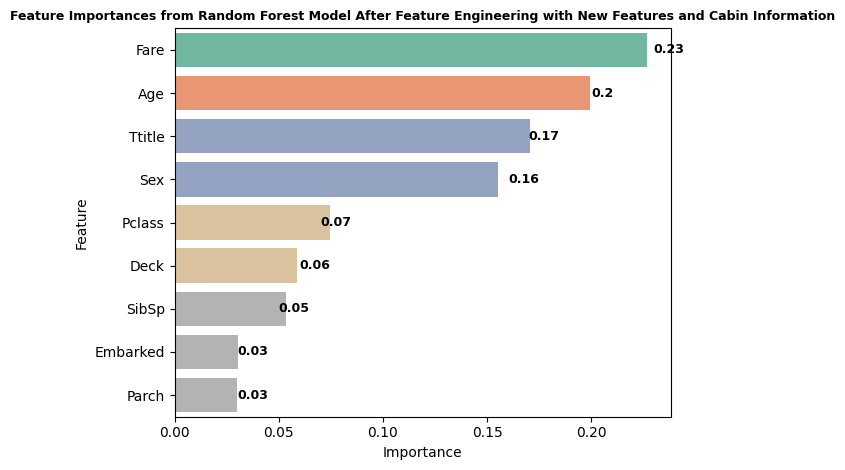

In [197]:
# Get feature importances from the Random Forest model
rf_importances3 = rf_model3.feature_importances_
feature_importance_df3 = pd.DataFrame({
    'Feature': new3_features,
    'Importance': rf_importances3
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df3.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df3, palette='Set2_r', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df3['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df3['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from Random Forest Model After Feature Engineering with New Features and Cabin Information", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

    Feature  Importance
7    Ttitle        0.38
0    Pclass        0.16
1       Sex        0.14
8      Deck        0.07
3     SibSp        0.06
5      Fare        0.05
6  Embarked        0.05
2       Age        0.04
4     Parch        0.04
--------------------------------------------------



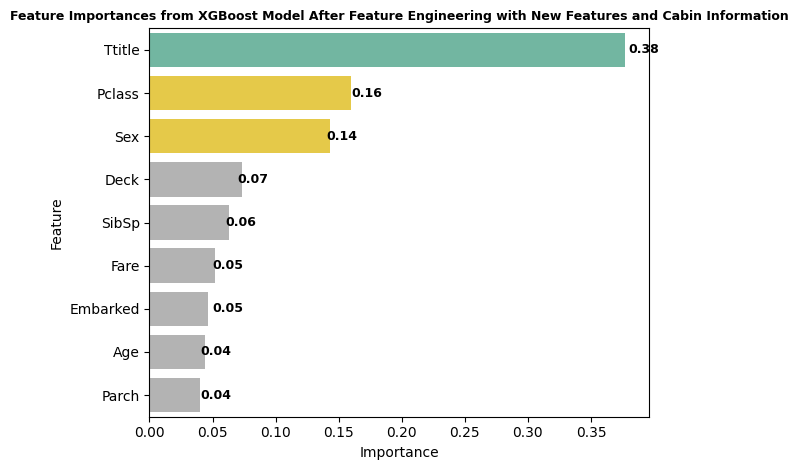

In [198]:
# Get feature importances from the XGBoost model
xgb_importances3 = xgb_model3.feature_importances_
feature_importance_df3 = pd.DataFrame({
    'Feature': new3_features,
    'Importance': xgb_importances3
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df3.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df3, palette='Set2_r', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df3['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df3['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from XGBoost Model After Feature Engineering with New Features and Cabin Information", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

**Permutation Importance**

    Feature  Importance
1       Sex       0.080
7    Ttitle       0.055
5      Fare       0.051
8      Deck       0.045
0    Pclass       0.037
2       Age       0.017
6  Embarked       0.013
3     SibSp       0.006
4     Parch      -0.003
--------------------------------------------------



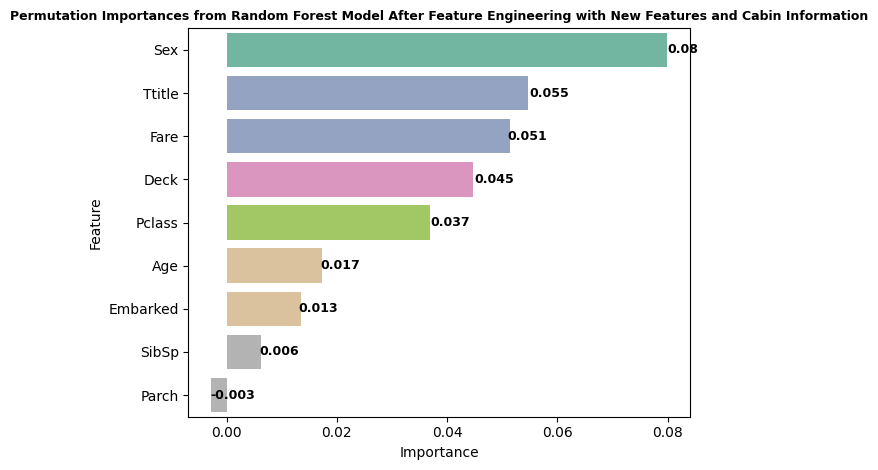

In [199]:
# Permutation importance with Random Forest model after feature engineering with new features
perm_importance_rf3= permutation_importance(rf_model3, x3_test, y3_test, n_repeats=10, random_state=42)
perm_importance_rf_df3 = pd.DataFrame({
    'Feature': new3_features,
    'Importance': perm_importance_rf3.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_rf_df3.round(3))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
ax = sb.barplot(
    x='Importance',
    y='Feature',
    data=perm_importance_rf_df3,
    palette='Set2_r',
    hue='Importance',
    legend=False
)

labels = perm_importance_rf_df3['Importance'].round(3).astype(str)
for index, value in enumerate(perm_importance_rf_df3['Importance'].round(3)):
    ax.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')

plt.title("Permutation Importances from Random Forest Model After Feature Engineering with New Features and Cabin Information", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


    Feature  Importance
7    Ttitle       0.108
0    Pclass       0.069
1       Sex       0.047
2       Age       0.039
5      Fare       0.018
6  Embarked       0.014
8      Deck       0.011
3     SibSp       0.002
4     Parch      -0.002
--------------------------------------------------



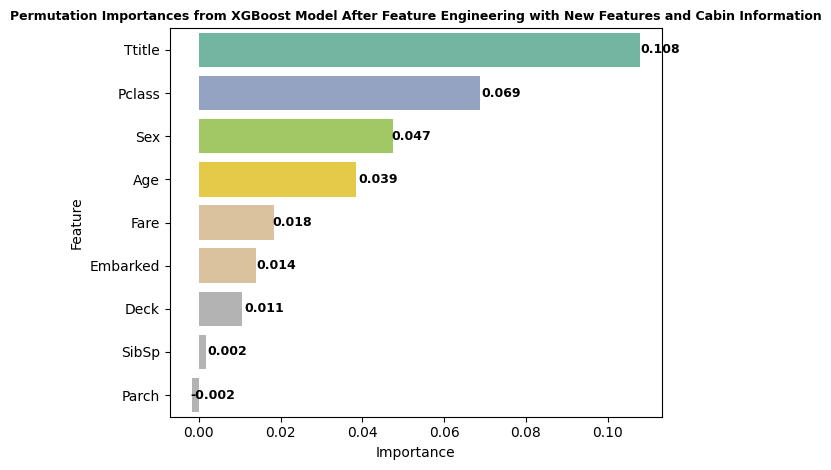

In [200]:
# Permutation importance with XGBoost model after feature engineering with new features
perm_importance_xgb3= permutation_importance(xgb_model3, x3_test, y3_test, n_repeats=10, random_state=42)
perm_importance_xgb_df3 = pd.DataFrame({
    'Feature': new3_features,
    'Importance': perm_importance_xgb3.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_xgb_df3.round(3))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
ax = sb.barplot(
    x='Importance',
    y='Feature',
    data=perm_importance_xgb_df3,
    palette='Set2_r',
    hue='Importance',
    legend=False
)

labels = perm_importance_xgb_df3['Importance'].round(3).astype(str)
for index, value in enumerate(perm_importance_xgb_df3['Importance'].round(3)):
    ax.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')

plt.title("Permutation Importances from XGBoost Model After Feature Engineering with New Features and Cabin Information", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [201]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Cross-validation for Random Forest
rf_cv_scores3 = cross_val_score(rf_model3, x3, y3, cv=5)
print("Random Forest Cross-Validation Scores:", rf_cv_scores3.mean().round(3))
print("Random Forest CV Mean Accuracy:", rf_cv_scores3.mean().round(3))
print("Random Forest Std:", rf_cv_scores3.std().round(3))
print("=" * 50 + "\n")

# Cross-validation for XGBoost
xgb_cv_scores3 = cross_val_score(xgb_model3, x3, y3, cv=5)
print("XGBoost Cross-Validation Scores:", xgb_cv_scores3.mean().round(3))
print("XGBoost CV Mean Accuracy:", xgb_cv_scores3.mean().round(3))
print("XGBoost Std:", xgb_cv_scores3.std().round(3))
print("=" * 50 + "\n")

#------------------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_stratified_scores3 = cross_val_score(rf_model3, x3, y3, cv=skf, scoring='recall')
print("Random Forest Stratified CV Scores:", rf_stratified_scores3.mean().round(3))
print("Random Forest Stratified CV Mean Accuracy:", rf_stratified_scores3.mean().round(3))
print("Random Forest Stratified CV Std:", rf_stratified_scores3.std().round(3))
print("=" * 50 + "\n")

xgb_stratified_scores3 = cross_val_score(xgb_model3, x3, y3, cv=skf, scoring='recall')
print("XGBoost Stratified CV Scores:", xgb_stratified_scores3.mean().round(3))
print("XGBoost Stratified CV Mean Accuracy:", xgb_stratified_scores3.mean().round(3))
print("XGBoost Stratified CV Std:", xgb_stratified_scores3.std().round(3))


Random Forest Cross-Validation Scores: 0.816
Random Forest CV Mean Accuracy: 0.816
Random Forest Std: 0.039

XGBoost Cross-Validation Scores: 0.844
XGBoost CV Mean Accuracy: 0.844
XGBoost Std: 0.016

Random Forest Stratified CV Scores: 0.751
Random Forest Stratified CV Mean Accuracy: 0.751
Random Forest Stratified CV Std: 0.029

XGBoost Stratified CV Scores: 0.749
XGBoost Stratified CV Mean Accuracy: 0.749
XGBoost Stratified CV Std: 0.02


### **FamilySize Feature testing for accuracy improvement**

In [202]:
# Create family size feature by combining SibSp and Parch and adding 1 for the passenger themselves
ml_data['family_size'] = ml_data['SibSp'] + ml_data['Parch'] + 1
test_data['family_size'] = test_data['SibSp'] + test_data['Parch'] + 1

print(ml_data[['SibSp','Parch','family_size']].head())
print(test_data[['SibSp','Parch','family_size']].head())

   SibSp  Parch  family_size
0      1      0            2
1      1      0            2
2      0      0            1
3      1      0            2
4      0      0            1
   SibSp  Parch  family_size
0      0      0            1
1      1      0            2
2      0      0            1
3      0      0            1
4      1      1            3


In [203]:
# IsAlone feature
ml_data['IsAlone'] = 0
ml_data.loc[ml_data['family_size'] == 1, 'IsAlone'] = 1

test_data['IsAlone'] = 0
test_data.loc[test_data['family_size'] == 1, 'IsAlone'] = 1

In [204]:
new_features4 = [
    'Pclass', 
    'Sex',
    'Age',
    'Fare',
    'Embarked',
    'Ttitle',
    'Deck',
    'family_size',
    'IsAlone'
]

x4 = ml_data[new_features4]
y4 = ml_data['Survived']
x4_train, x4_test, y4_train, y4_test = train_test_split(x4, y4, test_size=0.2, random_state=42)

In [205]:
# new_features and Train a Random Forest Classifier
rf_model4 = RandomForestClassifier(
    n_estimators=150,
    random_state=42)
rf_model4.fit(x4_train, y4_train)

rf_pred4 = rf_model4.predict(x4_test)
print("Random Forest Classifier Performance:", accuracy_score(y4_test, rf_pred4))
print("Confusion Matrix:\n", confusion_matrix(y4_test, rf_pred4))
print("Random Forest Recall:", recall_score(y4_test, rf_pred4))
print("Random Forest Precision:", precision_score(y4_test, rf_pred4))
print(classification_report(y4_test, rf_pred4))

print("=" * 50 + "\n")

# Train a xgboost Classifier
xgb_model4 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
xgb_model4.fit(x4_train, y4_train)
xgb_pred4 = xgb_model4.predict(x4_test)
print("XGBoost Classifier Performance:", accuracy_score(y4_test, xgb_pred4))
print("Confusion Matrix:\n", confusion_matrix(y4_test, xgb_pred4))
print("XGBoost Recall:", recall_score(y4_test, xgb_pred4))
print("XGBoost Precision:", precision_score(y4_test, xgb_pred4))
print(classification_report(y4_test, xgb_pred4))

Random Forest Classifier Performance: 0.8324022346368715
Confusion Matrix:
 [[90 15]
 [15 59]]
Random Forest Recall: 0.7972972972972973
Random Forest Precision: 0.7972972972972973
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179


XGBoost Classifier Performance: 0.8435754189944135
Confusion Matrix:
 [[94 11]
 [17 57]]
XGBoost Recall: 0.7702702702702703
XGBoost Precision: 0.8382352941176471
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       105
           1       0.84      0.77      0.80        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.84      0.84      0.84       179



       Feature  Importance
3         Fare        0.23
2          Age        0.20
1          Sex        0.17
5       Ttitle        0.16
0       Pclass        0.07
7  family_size        0.06
6         Deck        0.06
4     Embarked        0.03
8      IsAlone        0.01
--------------------------------------------------



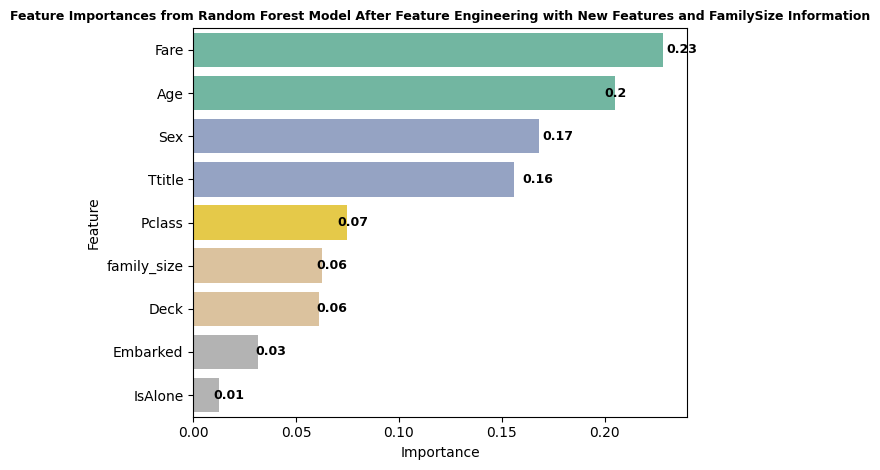

In [206]:
# Get feature importances from the Random Forest model
rf_importances4 = rf_model4.feature_importances_
feature_importance_df4 = pd.DataFrame({
    'Feature': new_features4,
    'Importance': rf_importances4
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df4.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df4, palette='Set2_r', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df4['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df4['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from Random Forest Model After Feature Engineering with New Features and FamilySize Information", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

       Feature  Importance
5       Ttitle        0.32
1          Sex        0.19
0       Pclass        0.16
7  family_size        0.08
6         Deck        0.07
3         Fare        0.05
2          Age        0.05
4     Embarked        0.04
8      IsAlone        0.03
--------------------------------------------------



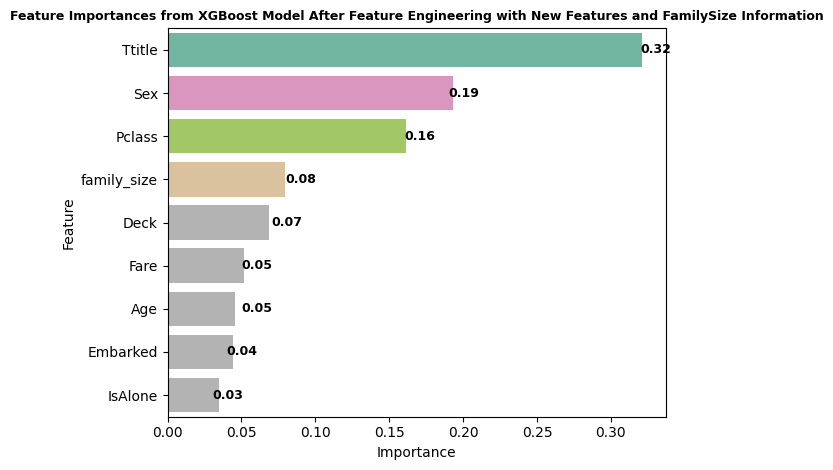

In [207]:
# Get feature importances from the XGBoost model
xgb_importances4 = xgb_model4.feature_importances_
feature_importance_df4 = pd.DataFrame({
    'Feature': new_features4,
    'Importance': xgb_importances4
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df4.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df4, palette='Set2_r', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df4['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df4['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from XGBoost Model After Feature Engineering with New Features and FamilySize Information", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

       Feature  Importance
1          Sex       0.085
5       Ttitle       0.054
3         Fare       0.046
0       Pclass       0.044
6         Deck       0.036
4     Embarked       0.013
2          Age       0.011
8      IsAlone       0.004
7  family_size       0.003
--------------------------------------------------



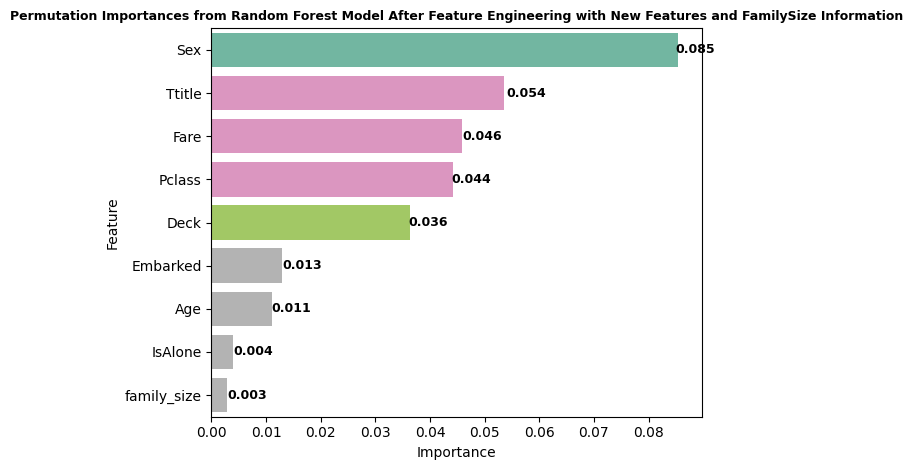

In [208]:
# Permutation importance with Random Forest model after feature engineering with new features
perm_importance_rf4= permutation_importance(rf_model4, x4_test, y4_test, n_repeats=10, random_state=42)
perm_importance_rf_df4 = pd.DataFrame({
    'Feature': new_features4,
    'Importance': perm_importance_rf4.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_rf_df4.round(3))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
ax = sb.barplot(
    x='Importance',
    y='Feature',
    data=perm_importance_rf_df4,
    palette='Set2_r',
    hue='Importance',
    legend=False
)

labels = perm_importance_rf_df4['Importance'].round(3).astype(str)
for index, value in enumerate(perm_importance_rf_df4['Importance'].round(3)):
    ax.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')

plt.title("Permutation Importances from Random Forest Model After Feature Engineering with New Features and FamilySize Information", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

       Feature  Importance
5       Ttitle       0.115
1          Sex       0.056
0       Pclass       0.049
2          Age       0.042
6         Deck       0.023
4     Embarked       0.020
3         Fare       0.017
7  family_size       0.009
8      IsAlone       0.003
--------------------------------------------------



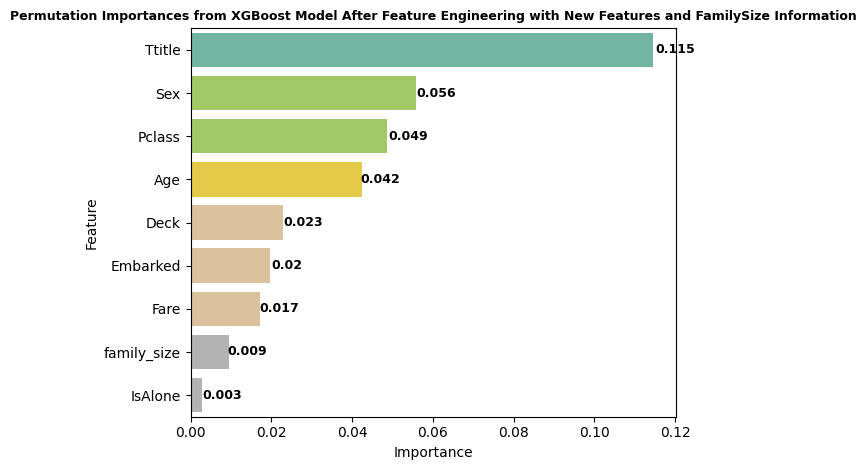

In [209]:
# Permutation importance with XGBoost model after feature engineering with new features
perm_importance_xgb4= permutation_importance(xgb_model4, x4_test, y4_test, n_repeats=10, random_state=42)
perm_importance_xgb_df4 = pd.DataFrame({
    'Feature': new_features4,
    'Importance': perm_importance_xgb4.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_xgb_df4.round(3))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
ax = sb.barplot(
    x='Importance',
    y='Feature',
    data=perm_importance_xgb_df4,
    palette='Set2_r',
    hue='Importance',
    legend=False
)

labels = perm_importance_xgb_df4['Importance'].round(3).astype(str)
for index, value in enumerate(perm_importance_xgb_df4['Importance'].round(3)):
    ax.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')

plt.title("Permutation Importances from XGBoost Model After Feature Engineering with New Features and FamilySize Information", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [210]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Cross-validation for Random Forest
rf_cv_scores4 = cross_val_score(rf_model4, x4, y4, cv=5)
print("Random Forest Cross-Validation Scores:", rf_cv_scores4.mean().round(3))
print("Random Forest CV Mean Accuracy:", rf_cv_scores4.mean().round(3))
print("Random Forest Std:", rf_cv_scores4.std().round(3))
print("=" * 50 + "\n")

# Cross-validation for XGBoost
xgb_cv_scores4 = cross_val_score(xgb_model4, x4, y4, cv=5)
print("XGBoost Cross-Validation Scores:", xgb_cv_scores4.mean().round(3))
print("XGBoost CV Mean Accuracy:", xgb_cv_scores4.mean().round(3))
print("XGBoost Std:", xgb_cv_scores4.std().round(3))
print("=" * 50 + "\n")

#------------------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_stratified_scores4 = cross_val_score(rf_model4, x4, y4, cv=skf, scoring='recall')
print("Random Forest Stratified CV Scores:", rf_stratified_scores4.mean().round(3))
print("Random Forest Stratified CV Mean Accuracy:", rf_stratified_scores4.mean().round(3))
print("Random Forest Stratified CV Std:", rf_stratified_scores4.std().round(3))
print("=" * 50 + "\n")

xgb_stratified_scores4 = cross_val_score(xgb_model4, x4, y4, cv=skf, scoring='recall')
print("XGBoost Stratified CV Scores:", xgb_stratified_scores4.mean().round(3))
print("XGBoost Stratified CV Mean Accuracy:", xgb_stratified_scores4.mean().round(3))
print("XGBoost Stratified CV Std:", xgb_stratified_scores4.std().round(3))


Random Forest Cross-Validation Scores: 0.815
Random Forest CV Mean Accuracy: 0.815
Random Forest Std: 0.038

XGBoost Cross-Validation Scores: 0.84
XGBoost CV Mean Accuracy: 0.84
XGBoost Std: 0.023

Random Forest Stratified CV Scores: 0.748
Random Forest Stratified CV Mean Accuracy: 0.748
Random Forest Stratified CV Std: 0.018

XGBoost Stratified CV Scores: 0.766
XGBoost Stratified CV Mean Accuracy: 0.766
XGBoost Stratified CV Std: 0.026


### **Fare per person for Testing Accuracy Improvement**

In [211]:
# Fare per person feature by dividing Fare by family size
ml_data['Fare_per_person'] = ml_data['Fare'] / ml_data['family_size'].replace(0,1)
test_data['Fare_per_person'] = test_data['Fare'] / test_data['family_size'].replace(0,1)

fare_person_median = ml_data['Fare_per_person'].median()

ml_data['Fare_per_person'] = ml_data['Fare_per_person'].fillna(fare_person_median)
test_data['Fare_per_person'] = test_data['Fare_per_person'].fillna(fare_person_median)

print(ml_data[['Fare','family_size','Fare_per_person']].head())
print(test_data[['Fare','family_size','Fare_per_person']].head())

      Fare  family_size  Fare_per_person
0   7.2500            2          3.62500
1  71.2833            2         35.64165
2   7.9250            1          7.92500
3  53.1000            2         26.55000
4   8.0500            1          8.05000
      Fare  family_size  Fare_per_person
0   7.8292            1         7.829200
1   7.0000            2         3.500000
2   9.6875            1         9.687500
3   8.6625            1         8.662500
4  12.2875            3         4.095833


In [212]:
new_features5 = [
'Pclass',
'Sex',
'Age',
'Fare',
'Fare_per_person',
'Embarked',
'Ttitle',
'Deck',
'family_size',
'IsAlone'
]

x5 = ml_data[new_features5]
y5 = ml_data['Survived']
x5_train, x5_test, y5_train, y5_test = train_test_split(x5, y5, test_size=0.2, random_state=42)

In [213]:
# new_features and Train a Random Forest Classifier
rf_model5 = RandomForestClassifier(
    n_estimators=150,
    random_state=42)
rf_model5.fit(x5_train, y5_train)

rf_pred5 = rf_model5.predict(x5_test)
print("Random Forest Classifier Performance:", accuracy_score(y5_test, rf_pred5))
print("Confusion Matrix:\n", confusion_matrix(y5_test, rf_pred5))
print("Random Forest Recall:", recall_score(y5_test, rf_pred5))
print("Random Forest Precision:", precision_score(y5_test, rf_pred5))
print(classification_report(y5_test, rf_pred5))

print("=" * 50 + "\n")

# Train a xgboost Classifier
xgb_model5 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
xgb_model5.fit(x5_train, y5_train)
xgb_pred5 = xgb_model5.predict(x5_test)
print(f"XGBoost Classifier Performance: {accuracy_score(y5_test, xgb_pred5):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y5_test, xgb_pred5))
print("XGBoost Recall:", recall_score(y5_test, xgb_pred5))
print("XGBoost Precision:", precision_score(y5_test, xgb_pred5))
print(classification_report(y5_test, xgb_pred5))

Random Forest Classifier Performance: 0.8547486033519553
Confusion Matrix:
 [[90 15]
 [11 63]]
Random Forest Recall: 0.8513513513513513
Random Forest Precision: 0.8076923076923077
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       105
           1       0.81      0.85      0.83        74

    accuracy                           0.85       179
   macro avg       0.85      0.85      0.85       179
weighted avg       0.86      0.85      0.86       179


XGBoost Classifier Performance: 0.86
Confusion Matrix:
 [[92 13]
 [12 62]]
XGBoost Recall: 0.8378378378378378
XGBoost Precision: 0.8266666666666667
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       105
           1       0.83      0.84      0.83        74

    accuracy                           0.86       179
   macro avg       0.86      0.86      0.86       179
weighted avg       0.86      0.86      0.86       179



           Feature  Importance
2              Age        0.19
6           Ttitle        0.17
3             Fare        0.15
1              Sex        0.15
4  Fare_per_person        0.14
0           Pclass        0.06
7             Deck        0.05
8      family_size        0.05
5         Embarked        0.02
9          IsAlone        0.01
--------------------------------------------------



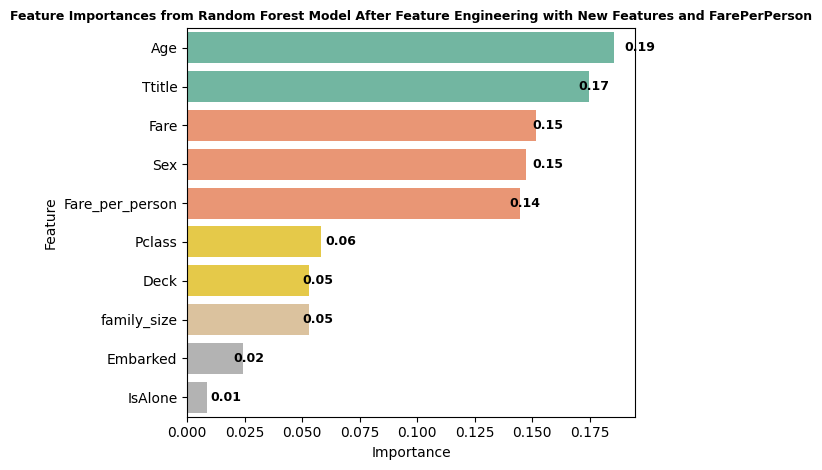

In [214]:
# Get feature importances from the Random Forest model
rf_importances5 = rf_model5.feature_importances_
feature_importance_df5 = pd.DataFrame({
    'Feature': new_features5,
    'Importance': rf_importances5
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df5.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df5, palette='Set2_r', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df5['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df5['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from Random Forest Model After Feature Engineering with New Features and FarePerPerson", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

           Feature  Importance
6           Ttitle        0.36
0           Pclass        0.18
1              Sex        0.13
8      family_size        0.09
7             Deck        0.06
4  Fare_per_person        0.04
3             Fare        0.04
2              Age        0.04
5         Embarked        0.04
9          IsAlone        0.02
--------------------------------------------------



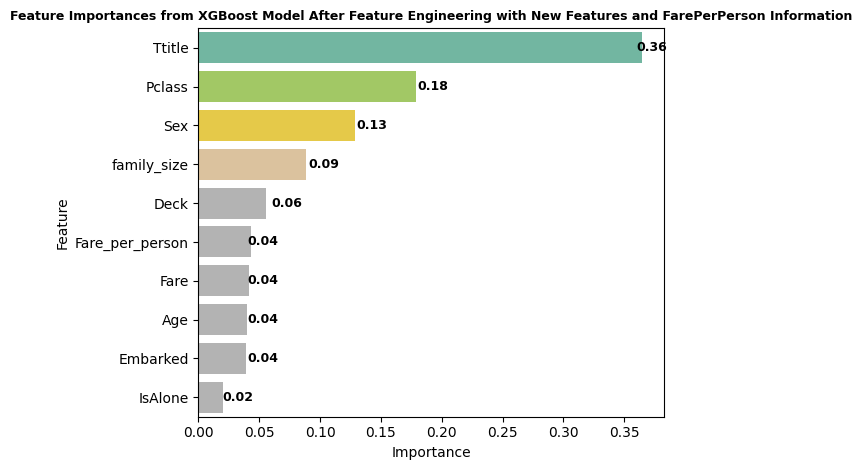

In [215]:
# Get feature importances from the XGBoost model
xgb_importances5 = xgb_model5.feature_importances_
feature_importance_df5 = pd.DataFrame({
    'Feature': new_features5,
    'Importance': xgb_importances5
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df5.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df5, palette='Set2_r', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df5['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df5['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from XGBoost Model After Feature Engineering with New Features and FarePerPerson Information", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

           Feature  Importance
6           Ttitle       0.075
1              Sex       0.063
4  Fare_per_person       0.054
0           Pclass       0.035
2              Age       0.030
7             Deck       0.027
5         Embarked       0.023
3             Fare       0.022
8      family_size       0.017
9          IsAlone       0.006
--------------------------------------------------



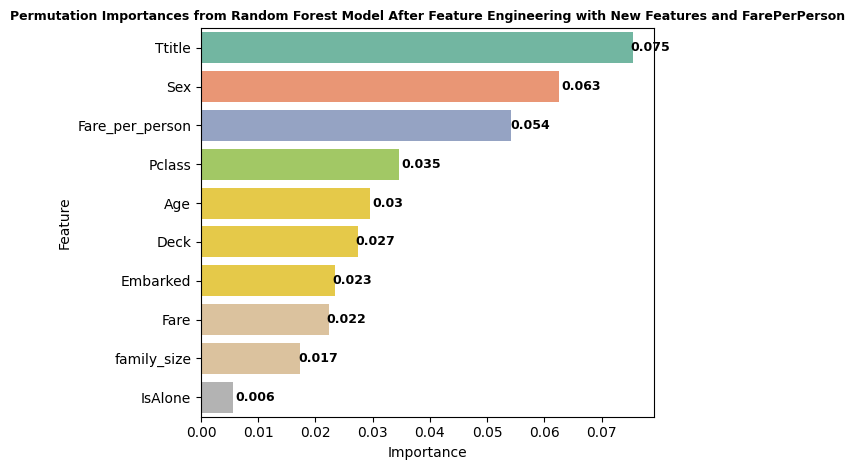

In [216]:
# Permutation importance with Random Forest model after feature engineering with new features
perm_importance_rf5= permutation_importance(rf_model5, x5_test, y5_test, n_repeats=10, random_state=42)
perm_importance_rf_df5 = pd.DataFrame({
    'Feature': new_features5,
    'Importance': perm_importance_rf5.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_rf_df5.round(3))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
ax = sb.barplot(
    x='Importance',
    y='Feature',
    data=perm_importance_rf_df5,
    palette='Set2_r',
    hue='Importance',
    legend=False
)

labels = perm_importance_rf_df5['Importance'].round(3).astype(str)
for index, value in enumerate(perm_importance_rf_df5['Importance'].round(3)):
    ax.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')

plt.title("Permutation Importances from Random Forest Model After Feature Engineering with New Features and FarePerPerson", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

           Feature  Importance
6           Ttitle       0.124
0           Pclass       0.064
4  Fare_per_person       0.057
2              Age       0.051
5         Embarked       0.032
1              Sex       0.027
8      family_size       0.022
3             Fare       0.014
7             Deck       0.012
9          IsAlone       0.003
--------------------------------------------------



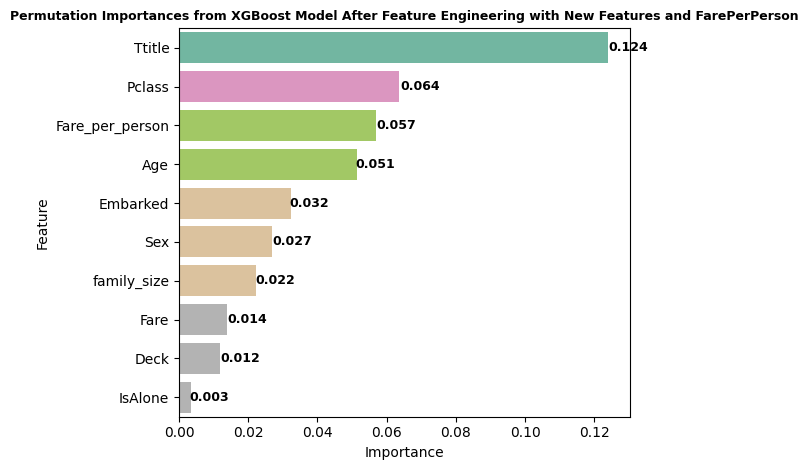

In [217]:
# Permutation importance with XGBoost model after feature engineering with new features
perm_importance_xgb5= permutation_importance(xgb_model5, x5_test, y5_test, n_repeats=10, random_state=42)
perm_importance_xgb_df5 = pd.DataFrame({
    'Feature': new_features5,
    'Importance': perm_importance_xgb5.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_xgb_df5.round(3))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
ax = sb.barplot(
    x='Importance',
    y='Feature',
    data=perm_importance_xgb_df5,
    palette='Set2_r',
    hue='Importance',
    legend=False
)

labels = perm_importance_xgb_df5['Importance'].round(3).astype(str)
for index, value in enumerate(perm_importance_xgb_df5['Importance'].round(3)):
    ax.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')

plt.title("Permutation Importances from XGBoost Model After Feature Engineering with New Features and FarePerPerson", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [218]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Cross-validation for Random Forest
rf_cv_scores5 = cross_val_score(rf_model5, x5, y5, cv=5)
print("Random Forest Cross-Validation Scores:", rf_cv_scores5.mean().round(3))
print("Random Forest CV Mean Accuracy:", rf_cv_scores5.mean().round(3))
print("Random Forest Std:", rf_cv_scores5.std().round(3))
print("=" * 50 + "\n")

# Cross-validation for XGBoost
xgb_cv_scores5 = cross_val_score(xgb_model5, x5, y5, cv=5)
print("XGBoost Cross-Validation Scores:", xgb_cv_scores5.mean().round(3))
print("XGBoost CV Mean Accuracy:", xgb_cv_scores5.mean().round(3))
print("XGBoost Std:", xgb_cv_scores5.std().round(3))
print("=" * 50 + "\n")

#------------------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_stratified_scores5 = cross_val_score(rf_model5, x5, y5, cv=skf, scoring='recall')
print("Random Forest Stratified CV Scores:", rf_stratified_scores5.mean().round(3))
print("Random Forest Stratified CV Mean Accuracy:", rf_stratified_scores5.mean().round(3))
print("Random Forest Stratified CV Std:", rf_stratified_scores5.std().round(3))
print("=" * 50 + "\n")

xgb_stratified_scores5 = cross_val_score(xgb_model5, x5, y5, cv=skf, scoring='recall')
print("XGBoost Stratified CV Scores:", xgb_stratified_scores5.mean().round(3))
print("XGBoost Stratified CV Mean Accuracy:", xgb_stratified_scores5.mean().round(3))
print("XGBoost Stratified CV Std:", xgb_stratified_scores5.std().round(3))


Random Forest Cross-Validation Scores: 0.817
Random Forest CV Mean Accuracy: 0.817
Random Forest Std: 0.033

XGBoost Cross-Validation Scores: 0.833
XGBoost CV Mean Accuracy: 0.833
XGBoost Std: 0.024

Random Forest Stratified CV Scores: 0.743
Random Forest Stratified CV Mean Accuracy: 0.743
Random Forest Stratified CV Std: 0.03

XGBoost Stratified CV Scores: 0.751
XGBoost Stratified CV Mean Accuracy: 0.751
XGBoost Stratified CV Std: 0.019


### **Age_pClass_Sex interaction to test for accuracy**

In [219]:
### improved age-pclass-sex interaction feature for survival prediction
# higher value = younger passenger, higher class, female advantage
for df in [ml_data, test_data]:
    class_factor = 4 - df['Pclass']   # 1st class=3, 2nd=2, 3rd=1
    sex_factor = 2 - df['Sex']     # female=2, male=1  (Sex: female=0, male=1)
    age_factor = 1 / (df['Age'] + 1)  # younger passengers get higher weight

    df['Age_Pclass_Sex'] = (class_factor * sex_factor * age_factor).round(4)

print(ml_data[['Age', 'Pclass', 'Sex', 'Age_Pclass_Sex']].head())
print(test_data[['Age', 'Pclass', 'Sex', 'Age_Pclass_Sex']].head())

    Age  Pclass  Sex  Age_Pclass_Sex
0  22.0       3    1          0.0435
1  38.0       1    0          0.1538
2  26.0       3    0          0.0741
3  35.0       1    0          0.1667
4  35.0       3    1          0.0278
    Age  Pclass  Sex  Age_Pclass_Sex
0  34.5       3    1          0.0282
1  47.0       3    0          0.0417
2  62.0       2    1          0.0317
3  27.0       3    1          0.0357
4  22.0       3    0          0.0870


In [220]:
ml_data[['Age_Pclass_Sex','Survived']].corr()

,Age_Pclass_Sex,Survived
Age_Pclass_Sex,1.000000,0.323517
Survived,0.323517,1.000000


In [221]:
new_features6 = [
'Pclass',
'Sex',
'Age',
'Fare',
'Fare_per_person',
'Embarked',
'Ttitle',
'family_size',
'IsAlone',
'Age_Pclass_Sex'
]

x6 = ml_data[new_features6]
y6 = ml_data['Survived']
x6_train, x6_test, y6_train, y6_test = train_test_split(x6, y6, test_size=0.2, random_state=42) 


In [222]:
# new_features and Train a Random Forest Classifier
rf_model6 = RandomForestClassifier(
    n_estimators=150,
    random_state=42)
rf_model6.fit(x6_train, y6_train)

rf_pred6 = rf_model6.predict(x6_test)
print("Random Forest Classifier Performance:", accuracy_score(y6_test, rf_pred6))
print("Confusion Matrix:\n", confusion_matrix(y6_test, rf_pred6))
print("Random Forest Recall:", recall_score(y6_test, rf_pred6))
print("Random Forest Precision:", precision_score(y6_test, rf_pred6))
print(classification_report(y6_test, rf_pred6))

print("=" * 50 + "\n")

# Train a xgboost Classifier
xgb_model6 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
xgb_model6.fit(x6_train, y6_train)
xgb_pred6 = xgb_model6.predict(x6_test)
print("XGBoost Classifier Performance:", accuracy_score(y6_test, xgb_pred6))
print("Confusion Matrix:\n", confusion_matrix(y6_test, xgb_pred6))
print("XGBoost Recall:", recall_score(y6_test, xgb_pred6))
print("XGBoost Precision:", precision_score(y6_test, xgb_pred6))
print(classification_report(y6_test, xgb_pred6))

Random Forest Classifier Performance: 0.8379888268156425
Confusion Matrix:
 [[94 11]
 [18 56]]
Random Forest Recall: 0.7567567567567568
Random Forest Precision: 0.835820895522388
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       105
           1       0.84      0.76      0.79        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179


XGBoost Classifier Performance: 0.8435754189944135
Confusion Matrix:
 [[92 13]
 [15 59]]
XGBoost Recall: 0.7972972972972973
XGBoost Precision: 0.8194444444444444
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       105
           1       0.82      0.80      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.84      0.84      0.84       179



           Feature  Importance
9   Age_Pclass_Sex        0.21
4  Fare_per_person        0.15
6           Ttitle        0.15
3             Fare        0.14
2              Age        0.11
1              Sex        0.10
7      family_size        0.06
0           Pclass        0.05
5         Embarked        0.02
8          IsAlone        0.01
--------------------------------------------------



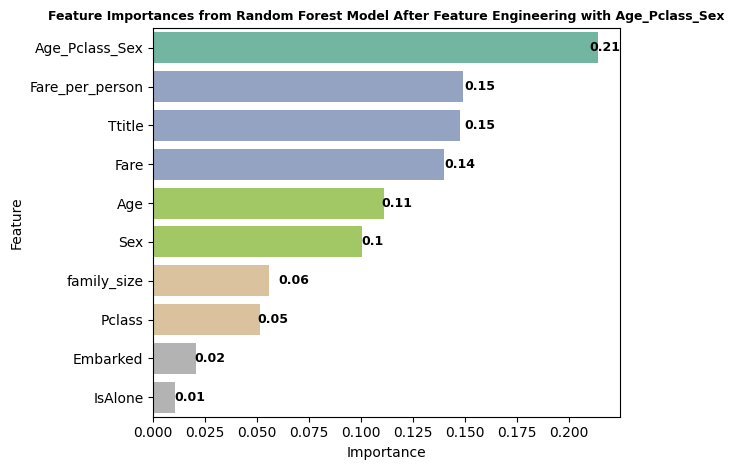

In [223]:
# Get feature importances from the Random Forest model
rf_importances6 = rf_model6.feature_importances_
feature_importance_df6 = pd.DataFrame({
    'Feature': new_features6,
    'Importance': rf_importances6
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df6.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df6, palette='Set2_r', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df6['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df6['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from Random Forest Model After Feature Engineering with Age_Pclass_Sex", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

           Feature  Importance
6           Ttitle        0.36
0           Pclass        0.17
1              Sex        0.17
7      family_size        0.08
9   Age_Pclass_Sex        0.05
3             Fare        0.04
4  Fare_per_person        0.04
5         Embarked        0.04
2              Age        0.03
8          IsAlone        0.03
--------------------------------------------------



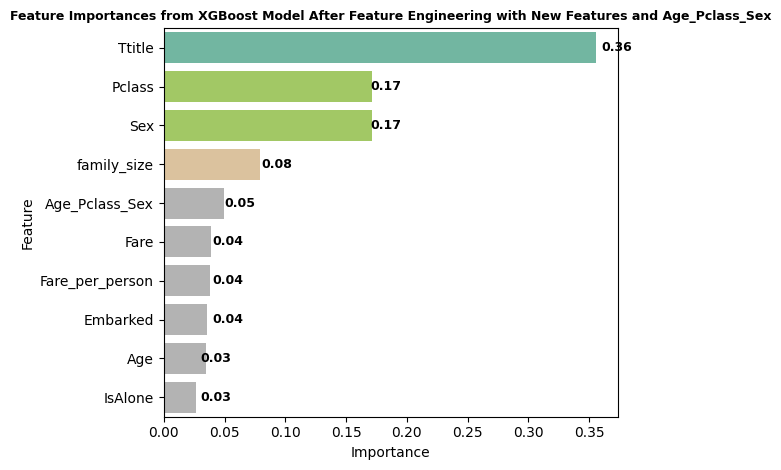

In [224]:
# Get feature importances from the XGBoost model
xgb_importances6 = xgb_model6.feature_importances_
feature_importance_df6 = pd.DataFrame({
    'Feature': new_features6,
    'Importance': xgb_importances6
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df6.round(2))
print("-" * 50 + "\n")
# print feature importances from the model with bar plot and label

sb.barplot(x='Importance', y='Feature', data=feature_importance_df6, palette='Set2_r', hue='Importance', dodge=False, legend=False)
labels = feature_importance_df6['Importance'].round(2).astype(str)
for index, value in enumerate(feature_importance_df6['Importance'].round(2)):
    plt.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')
plt.title("Feature Importances from XGBoost Model After Feature Engineering with New Features and Age_Pclass_Sex", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

           Feature  Importance
4  Fare_per_person       0.035
9   Age_Pclass_Sex       0.028
0           Pclass       0.015
8          IsAlone       0.014
5         Embarked       0.011
7      family_size       0.008
6           Ttitle       0.007
1              Sex       0.002
3             Fare      -0.000
2              Age      -0.006
--------------------------------------------------



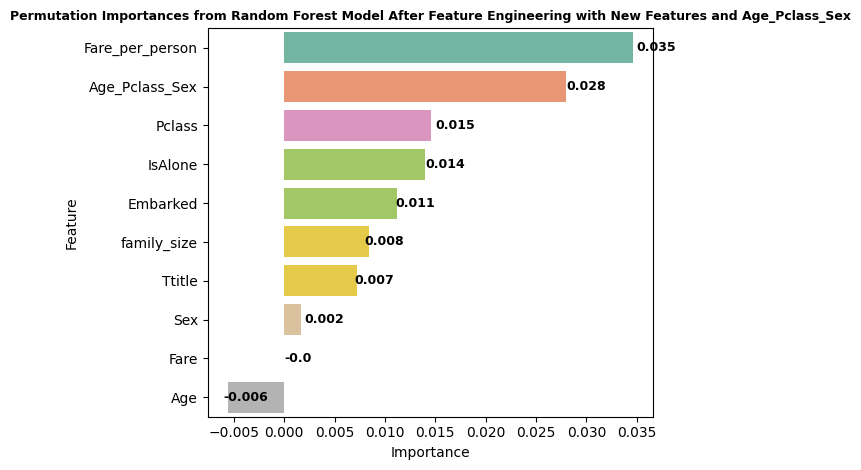

In [225]:
# Permutation importance with Random Forest model after feature engineering with new features
perm_importance_rf6= permutation_importance(rf_model6, x6_test, y6_test, n_repeats=10, random_state=42)
perm_importance_rf_df6 = pd.DataFrame({
    'Feature': new_features6,
    'Importance': perm_importance_rf6.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_rf_df6.round(3))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
ax = sb.barplot(
    x='Importance',
    y='Feature',
    data=perm_importance_rf_df6,
    palette='Set2_r',
    hue='Importance',
    legend=False
)

labels = perm_importance_rf_df6['Importance'].round(3).astype(str)
for index, value in enumerate(perm_importance_rf_df6['Importance'].round(3)):
    ax.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')

plt.title("Permutation Importances from Random Forest Model After Feature Engineering with New Features and Age_Pclass_Sex", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

           Feature  Importance
9   Age_Pclass_Sex       0.120
4  Fare_per_person       0.065
6           Ttitle       0.051
2              Age       0.016
5         Embarked       0.006
3             Fare       0.006
0           Pclass       0.004
7      family_size       0.002
8          IsAlone       0.000
1              Sex      -0.001
--------------------------------------------------



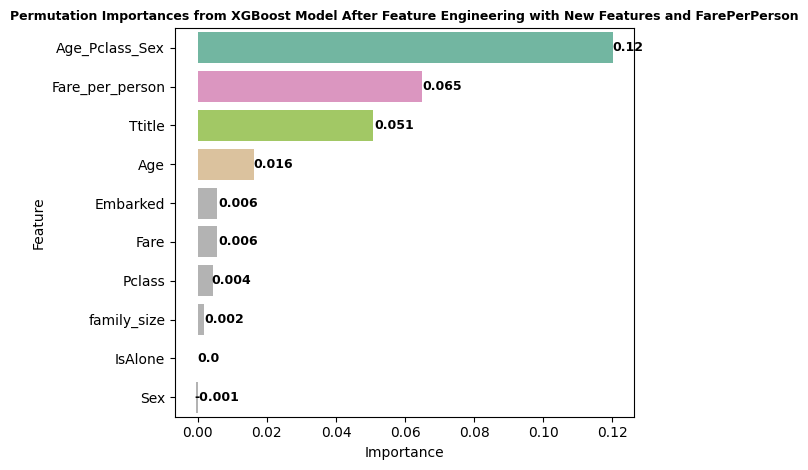

In [226]:
# Permutation importance with XGBoost model after feature engineering with new features
perm_importance_xgb6= permutation_importance(xgb_model6, x6_test, y6_test, n_repeats=10, random_state=42)
perm_importance_xgb_df6 = pd.DataFrame({
    'Feature': new_features6,
    'Importance': perm_importance_xgb6.importances_mean
}).sort_values(by='Importance', ascending=False)
print(perm_importance_xgb_df6.round(3))
print("-" * 50 + "\n")
# print permutation importance with bar plot and label
ax = sb.barplot(
    x='Importance',
    y='Feature',
    data=perm_importance_xgb_df6,
    palette='Set2_r',
    hue='Importance',
    legend=False
)

labels = perm_importance_xgb_df6['Importance'].round(3).astype(str)
for index, value in enumerate(perm_importance_xgb_df6['Importance'].round(3)):
    ax.text(value, index, labels.iloc[index], va='center', ha='left', fontsize=9, fontweight='bold', color='black')

plt.title("Permutation Importances from XGBoost Model After Feature Engineering with New Features and FarePerPerson", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [227]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Cross-validation for Random Forest
rf_cv_scores6 = cross_val_score(rf_model6, x6, y6, cv=5)
print("Random Forest Cross-Validation Scores:", rf_cv_scores6.mean().round(3))
print("Random Forest CV Mean Accuracy:", rf_cv_scores6.mean().round(3))
print("Random Forest Std:", rf_cv_scores6.std().round(3))
print("=" * 50 + "\n")

# Cross-validation for XGBoost
xgb_cv_scores6 = cross_val_score(xgb_model6, x6, y6, cv=5)
print("XGBoost Cross-Validation Scores:", xgb_cv_scores6.mean().round(3))
print("XGBoost CV Mean Accuracy:", xgb_cv_scores6.mean().round(3))
print("XGBoost Std:", xgb_cv_scores6.std().round(3))
print("=" * 50 + "\n")

#------------------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_stratified_scores6 = cross_val_score(rf_model6, x6, y6, cv=skf, scoring='recall')
print("Random Forest Stratified CV Scores:", rf_stratified_scores6.mean().round(3))
print("Random Forest Stratified CV Mean Accuracy:", rf_stratified_scores6.mean().round(3))
print("Random Forest Stratified CV Std:", rf_stratified_scores6.std().round(3))
print("=" * 50 + "\n")

xgb_stratified_scores6 = cross_val_score(xgb_model6, x6, y6, cv=skf, scoring='recall')
print("XGBoost Stratified CV Scores:", xgb_stratified_scores6.mean().round(3))
print("XGBoost Stratified CV Mean Accuracy:", xgb_stratified_scores6.mean().round(3))
print("XGBoost Stratified CV Std:", xgb_stratified_scores6.std().round(3))


Random Forest Cross-Validation Scores: 0.822
Random Forest CV Mean Accuracy: 0.822
Random Forest Std: 0.035

XGBoost Cross-Validation Scores: 0.838
XGBoost CV Mean Accuracy: 0.838
XGBoost Std: 0.031

Random Forest Stratified CV Scores: 0.746
Random Forest Stratified CV Mean Accuracy: 0.746
Random Forest Stratified CV Std: 0.021

XGBoost Stratified CV Scores: 0.745
XGBoost Stratified CV Mean Accuracy: 0.745
XGBoost Stratified CV Std: 0.034


In [228]:
# Combine and print all accuracy scores, recall scores, precision scores, feature importances, permutation importances and cross-validation scores from all models (from feature to till new_features6) of both RF and XGBoost in a table
def build_result_row(model_name, y_true, y_pred, feature_names, feature_importances, perm_importance_obj, cv_scores, strat_scores):
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 3),
        'Recall': round(recall_score(y_true, y_pred), 3),
        'Precision': round(precision_score(y_true, y_pred), 3),
        'Feature_Importances': {
            f: round(float(v), 3) for f, v in zip(feature_names, feature_importances)
        },
        'Permutation_Importances': {
            f: round(float(v), 3) for f, v in zip(feature_names, perm_importance_obj.importances_mean)
        },
        'CV_Mean_Accuracy': round(cv_scores.mean(), 3),
        'CV_Std': round(cv_scores.std(), 3),
        'Stratified_CV_Mean_Recall': round(strat_scores.mean(), 3),
        'Stratified_CV_Std_Recall': round(strat_scores.std(), 3)
    }

results_df = pd.DataFrame([
    build_result_row('RF_Feature', y_test, rf_pred, features, rf_importances, perm_importance_rf, rf_cv_scores, rf_stratified_scores),
    build_result_row('XGB_Feature', y_test, xgb_pred, features, xgb_importances, perm_importance_xgb, xgb_cv_scores, xgb_stratified_scores),

    build_result_row('RF_New_Features', y1_test, rf_pred2, new_features, rf_importances2, perm_importance_rf2, rf_cv_scores2, rf_stratified_scores2),
    build_result_row('XGB_New_Features', y1_test, xgb_pred2, new_features, xgb_importances2, perm_importance_xgb2, xgb_cv_scores2, xgb_stratified_scores2),

    build_result_row('RF_New_Features_Cabin', y3_test, rf_pred3, new3_features, rf_importances3, perm_importance_rf3, rf_cv_scores3, rf_stratified_scores3),
    build_result_row('XGB_New_Features_Cabin', y3_test, xgb_pred3, new3_features, xgb_importances3, perm_importance_xgb3, xgb_cv_scores3, xgb_stratified_scores3),

    build_result_row('RF_New_Features_FamilySize', y4_test, rf_pred4, new_features4, rf_importances4, perm_importance_rf4, rf_cv_scores4, rf_stratified_scores4),
    build_result_row('XGB_New_Features_FamilySize', y4_test, xgb_pred4, new_features4, xgb_importances4, perm_importance_xgb4, xgb_cv_scores4, xgb_stratified_scores4),

    build_result_row('RF_New_Features_FarePerPerson', y5_test, rf_pred5, new_features5, rf_importances5, perm_importance_rf5, rf_cv_scores5, rf_stratified_scores5),
    build_result_row('XGB_New_Features_FarePerPerson', y5_test, xgb_pred5, new_features5, xgb_importances5, perm_importance_xgb5, xgb_cv_scores5, xgb_stratified_scores5),

    build_result_row('RF_New_Features_AgePclassSex', y6_test, rf_pred6, new_features6, rf_importances6, perm_importance_rf6, rf_cv_scores6, rf_stratified_scores6),
    build_result_row('XGB_New_Features_AgePclassSex', y6_test, xgb_pred6, new_features6, xgb_importances6, perm_importance_xgb6, xgb_cv_scores6, xgb_stratified_scores6),
])
results_df

,Model,Accuracy,Recall,Precision,Feature_Importances,Permutation_Importances,CV_Mean_Accuracy,CV_Std,Stratified_CV_Mean_Recall,Stratified_CV_Std_Recall
0,RF_Feature,0.827,0.770,0.803,"{'Pclass': 0.087, 'Sex': 0.262, 'Age': 0.253, ...","{'Pclass': 0.07, 'Sex': 0.184, 'Age': 0.031, '...",0.808,0.030,0.757,0.022
1,XGB_Feature,0.849,0.797,0.831,"{'Pclass': 0.159, 'Sex': 0.531, 'Age': 0.061, ...","{'Pclass': 0.07, 'Sex': 0.164, 'Age': 0.07, 'S...",0.836,0.029,0.751,0.019
2,RF_New_Features,0.855,0.838,0.816,"{'Pclass': 0.079, 'Sex': 0.15, 'Age': 0.218, '...","{'Pclass': 0.06, 'Sex': 0.063, 'Age': 0.034, '...",0.802,0.026,0.746,0.021
3,XGB_New_Features,0.849,0.824,0.813,"{'Pclass': 0.147, 'Sex': 0.185, 'Age': 0.048, ...","{'Pclass': 0.084, 'Sex': 0.063, 'Age': 0.05, '...",0.835,0.018,0.766,0.025
4,RF_New_Features_Cabin,0.827,0.770,0.803,"{'Pclass': 0.074, 'Sex': 0.155, 'Age': 0.2, 'S...","{'Pclass': 0.037, 'Sex': 0.08, 'Age': 0.017, '...",0.816,0.039,0.751,0.029
5,XGB_New_Features_Cabin,0.838,0.784,0.817,"{'Pclass': 0.16, 'Sex': 0.143, 'Age': 0.044, '...","{'Pclass': 0.069, 'Sex': 0.047, 'Age': 0.039, ...",0.844,0.016,0.749,0.020
6,RF_New_Features_FamilySize,0.832,0.797,0.797,"{'Pclass': 0.075, 'Sex': 0.168, 'Age': 0.205, ...","{'Pclass': 0.044, 'Sex': 0.085, 'Age': 0.011, ...",0.815,0.038,0.748,0.018
7,XGB_New_Features_FamilySize,0.844,0.770,0.838,"{'Pclass': 0.161, 'Sex': 0.193, 'Age': 0.045, ...","{'Pclass': 0.049, 'Sex': 0.056, 'Age': 0.042, ...",0.840,0.023,0.766,0.026
8,RF_New_Features_FarePerPerson,0.855,0.851,0.808,"{'Pclass': 0.058, 'Sex': 0.147, 'Age': 0.185, ...","{'Pclass': 0.035, 'Sex': 0.063, 'Age': 0.03, '...",0.817,0.033,0.743,0.030
9,XGB_New_Features_FarePerPerson,0.860,0.838,0.827,"{'Pclass': 0.179, 'Sex': 0.129, 'Age': 0.04, '...","{'Pclass': 0.064, 'Sex': 0.027, 'Age': 0.051, ...",0.833,0.024,0.751,0.019


In [229]:
#Why SHAP?
# SHAP (SHapley Additive exPlanations) is a powerful tool for interpreting machine learning models, especially complex ones like Random Forests and XGBoost. It provides a unified measure of feature importance based on cooperative game theory, allowing us to understand how each feature contributes to the model's predictions. SHAP values can help identify which features are driving the predictions, whether they have a positive or negative impact, and how they interact with other features. This level of interpretability is crucial for building trust in the model and making informed decisions based on its outputs.
# for Titanic dataset, SHAP can help us understand which features (like Age, Fare, Pclass, etc.) are most influential in predicting survival, and how they interact with each other to affect the outcome. This can provide valuable insights into the factors that contributed to survival on the Titanic and help us build more accurate and interpretable models.

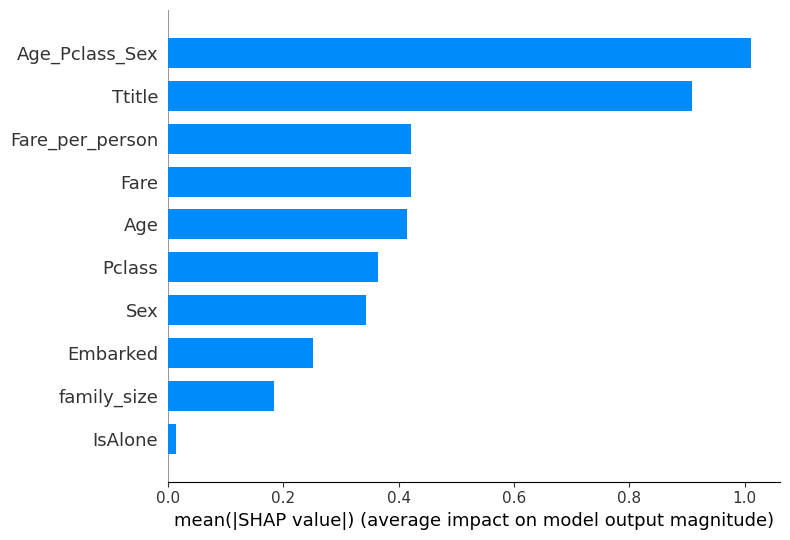

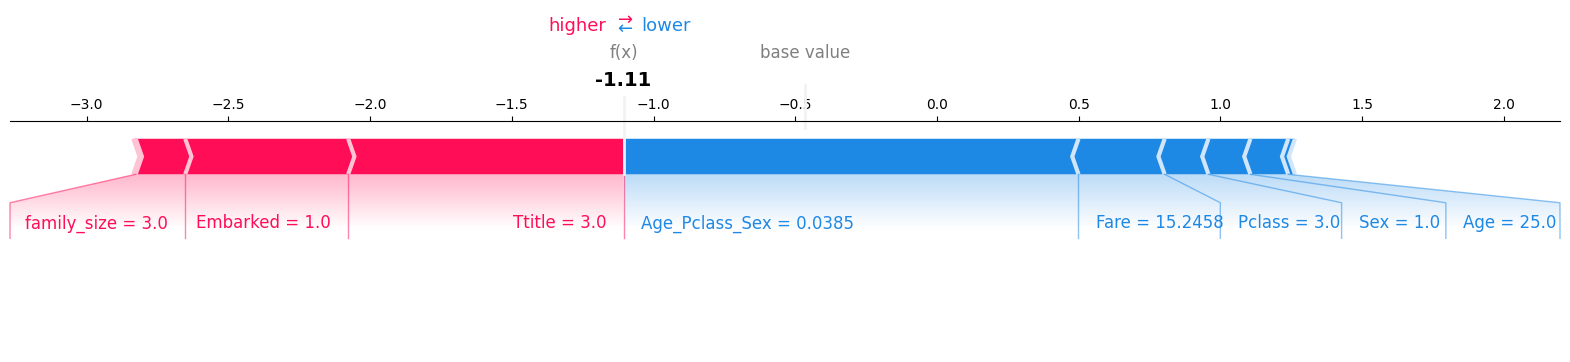

In [230]:
#SHAP values for the best performing model (XGBoost with new features and Age_Pclass
import shap

explainer = shap.TreeExplainer(xgb_model6)
shap_values = explainer.shap_values(x6_test)
shap.summary_plot(shap_values, x6_test, feature_names=new_features6, plot_type="bar", cmap=plt.cm.bwr, show=True, title="SHAP Summary Plot for XGBoost Model with New Features")
shap.force_plot(explainer.expected_value, shap_values[0,:], x6_test.iloc[0,:], feature_names=new_features6, matplotlib=True)

### Based on the SHAP summary plot, the most important features for predicting survival in the XGBoost model with new features and Age_Pclass_Sex interaction are:
- 1. Age_Pclass_Sex: This interaction feature has the highest SHAP value, indicating it is the most influential feature in the model. It captures the combined effect of age, passenger class, and  sex on survival, with younger passengers in higher classes and  females having a higher likelihood of survival.
- 2. Fare_per_person: This feature is also highly important, suggesting that the fare paid per person (which accounts for family size) is a strong predictor of survival. Passengers who paid higher fares per person were more likely to survive.
- 3. Pclass: Passenger class is a significant predictor, with higher classes (1st class) being associated with higher survival rates compared to lower classes (2nd and 3rd class).
- 4. Sex: The sex feature is important, with females having a higher likelihood of survival compared to males, which is consistent with historical accounts of the Titanic disaster.
- 5. Age: Age is also a relevant feature, with younger passengers generally having a higher chance of survival compared to older passengers.
- 6. IsAlone: This feature indicates whether a passenger was alone or with family. Passengers who were alone had a different survival rate compared to those with family, making it an important factor in the model.
- 7. Embarked: The port of embarkation also has some influence on survival, with certain ports being associated with higher survival rates.
- 8. Ttitle: The title extracted from the passenger's name (e.g., Mr., Mrs., Miss) also contributes to the model's predictions, as it can capture social status and other relevant information.
- 9. family_size: The size of the passenger's family can also impact survival, with larger families potentially having different survival dynamics compared to smaller families or individuals.
- 10. Deck: The deck on which the passenger was located may also have some influence on survival, although it appears to be less important than the other features mentioned above. 
Overall, the SHAP summary plot provides valuable insights into which features are driving the model's predictions and how they interact with each other to influence survival outcomes on the Titanic.
@PhyoThor


### **Build a prediction function by accepting user input for the features and returning the predicted survival probability from the best performing model (XGBoost with new features and Age_Pclass_Sex)**

In [231]:
# def predict_survival(input_data):
#     # Create a DataFrame from the input data
#     input_df = pd.DataFrame([input_data], columns=new_features6)
    
#     # Ensure all features are present in the input, if not add them with default values
#     for feature in new_features6:
#         if feature not in input_df.columns:
#             input_df[feature] = 0  # Default value for missing features
    
#     # Predict survival probability using the best performing model (XGBoost with new features and Age_Pclass_Sex)
#     survival_probability = xgb_model6.predict_proba(input_df)[:, 1][0]  # Probability of survival (class 1)
#     return round(survival_probability, 3)

# # Ask user for input values for the features
# user_input = {
#     'Pclass': int(input("Enter Pclass (1, 2, or 3): ")),
#     'Sex': int(input("Enter Sex (0 for female, 1 for male): ")),
#     'Age': float(input("Enter Age: ")),
#     'Fare': float(input("Enter Fare: ")),
#     'embarked': int(input("Enter Embarked (0 for S, 1 for C, 2 for Q): ")),
#     'Ttitle': int(input("Enter Ttitle (0 for Mr, 1 for Miss, 2 for Mrs, 3 for Master, 4 for Rare): "))
# }
# # Calculate family_size and IsAlone based on user input
# family_size = int(input("Enter family size (number of siblings/spouses + number of parents/children + 1 for self or Zero for no family): "))
# user_input['family_size'] = family_size
# user_input['IsAlone'] = 1 if family_size == 1 else 0
# # Calculate Age_Pclass_Sex interaction feature
# class_factor = 4 - user_input['Pclass']   # 1st class=3, 2nd=2, 3rd=1   
# sex_factor = 2 - user_input['Sex']     # female=2,      male=1
# age_factor = 1 / (user_input['Age'] + 1)  # younger passengers get higher weight
# user_input['Age_Pclass_Sex'] = round(class_factor * sex_factor * age_factor, 3)
# # Predict survival probability
# predicted_probability = predict_survival(user_input)
# if predicted_probability >= 0.5:
#     print("The model predicts that the passenger would have survived. Due to ", str(user_input['Age']), " & Passenger Class ", str(user_input['Pclass']), " & Gender ", str(user_input['Sex']), " interaction feature, the model gives higher survival probability to younger passengers in higher class and female passengers.")
# else:    print("The model predicts that the passenger would not have survived. Due to ", str(user_input['Age']), "& Passenger Class ", str(user_input['Pclass']), " & Gender ", str(user_input['Sex']), " interaction feature, the model gives lower survival probability to older passengers in lower class and male passengers.")
# print("=" * 80 + "\n")
# print("Note: This prediction is based on the XGBoost model with new features and Age_Pclass_Sex interaction, and is not a guarantee of actual survival.")